# Prediction du Comportement des Clients avec l'IA dans une Banque
## Scoring Bancaire — ANI-IA 4

**Objectifs :**
- Comparer differents types de classificateurs
- Creer un ensemble de modeles (Voting Classifier)
- Creer un classificateur personnalise base sur un reseau de neurones (MLP)
- Classer les clients en fonction des modeles developpes

**Dataset :** [UCI Machine Learning Repository — Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)



## 1. Installation des dependances et Imports

In [1]:
# Installation (decommentier si necessaire)
# !pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style("whitegrid")

print("Tous les imports realises avec succes !")

Tous les imports realises avec succes !



## 2. Chargement et Exploration des Donnees

Le dataset **Bank Marketing** contient des informations sur les clients d'une banque portugaise
et les resultats de campagnes de marketing telephonique direct.

In [2]:
from pathlib import Path
from zipfile import ZipFile
from urllib.request import urlretrieve

project_dir = Path.cwd()
local_file  = project_dir / 'bank_marketing_uci.csv'
archive_file= project_dir / 'bank.zip'
source_url  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip'

if local_file.exists():
    df = pd.read_csv(local_file)
    print(f"Dataset charge depuis le fichier local : {local_file}")
else:
    try:
        if not archive_file.exists():
            print(f"Telechargement du dataset depuis UCI : {source_url}")
            urlretrieve(source_url, archive_file)
        with ZipFile(archive_file) as archive:
            with archive.open('bank-full.csv') as csv_file:
                df = pd.read_csv(csv_file, sep=';')
        df.to_csv(local_file, index=False)
        print("Dataset telecharge depuis UCI et sauvegarde localement")
    except Exception as error:
        raise RuntimeError(
            "Impossible de telecharger le dataset. Verifiez la connexion Internet."
        ) from error

print(f"Shape du dataset : {df.shape}")
print(f"Colonnes : {list(df.columns)}")

Dataset charge depuis le fichier local : c:\Users\LENOVO\Desktop\tp-eneo\bank_marketing_uci.csv
Shape du dataset : (45211, 17)
Colonnes : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [3]:
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
print("=" * 55)
print("   INFORMATIONS GENERALES DU DATASET")
print("=" * 55)
print(df.info())

   INFORMATIONS GENERALES DU DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


In [7]:
df.shape

(45211, 17)




##  Description Générale
Ce dataset contient des données relatives à des campagnes de marketing direct d'une institution bancaire portugaise. L'objectif est de prédire si un client va souscrire à un dépôt à terme (term deposit).

**Nombre de lignes**: 45,211 enregistrements  
**Nombre de colonnes**: 17 variables



##  Détail de Chaque Colonne

### **1. âge (age)** - TYPE: Numérique
**Description**: L'âge du client en années.  
**Valeurs**: Nombres entiers positifs (ex: 25, 46, 58, 65...)  
**Importance**: Permet d'analyser le comportement des clients selon leur tranche d'âge.  
**Exemple**: Un client de 46 ans



### **2. emploi (job)** - TYPE: Catégorique
**Description**: Le type d'emploi/profession du client.  
**Catégories possibles**:
- "admin." → Administration
- "technician" → Technicien
- "management" → Gestion/Cadre
- "entrepreneur" → Entrepreneur
- "blue-collar" → Ouvrier
- "services" → Services
- "retired" → Retraité
- "housemaid" → Femme de ménage
- "student" → Étudiant
- "unemployed" → Sans emploi
- "self-employed" → Travailleur indépendant
- "unknown" → Inconnu

**Importance**: La profession influence souvent les décisions financières.  
**Exemple**: "management", "admin.", "services"



### **3. état_civil (marital)** - TYPE: Catégorique
**Description**: L'état matrimonial du client.  
**Catégories possibles**:
- "married" → Marié(e)
- "single" → Célibataire
- "divorced" → Divorcé(e) ou veuf/veuve

**Note**: La catégorie "divorced" inclut aussi les personnes veuves.  
**Importance**: L'état civil peut affecter la capacité d'épargne et les besoins financiers.  
**Exemple**: "married", "single", "divorced"


### **4. éducation (education)** - TYPE: Catégorique
**Description**: Le niveau d'éducation/formation du client.  
**Catégories possibles**:
- "primary" → Éducation primaire
- "secondary" → Éducation secondaire
- "tertiary" → Éducation tertiaire (université/études supérieures)
- "unknown" → Inconnu

**Importance**: Le niveau d'éducation peut influencer la compréhension des produits financiers et la propension à investir.  
**Exemple**: "tertiary", "secondary", "primary"


### **5. crédit_défaut (default)** - TYPE: Binaire (Oui/Non)
**Description**: Le client a-t-il un crédit en défaut (impayé) ?  
**Valeurs**:
- "yes" → Oui, le client a un crédit en défaut
- "no" → Non, le client n'a pas de crédit en défaut

**Importance**: C'est un indicateur majeur de risque de crédit et de fiabilité financière.  
**Exemple**: "no", "yes"



### **6. solde (balance)** - TYPE: Numérique
**Description**: Le solde moyen annuel du client, en euros (€).  
**Valeurs**: Nombres entiers (positifs ou négatifs)  
**Plage observée**: Peut être négatif (découvert) ou positif (économies)  
**Importance**: Reflète la santé financière et la capacité d'épargne du client.  
**Exemple**: 2143 €, 825 €, -2496 € (découvert)



### **7. prêt_immobilier (housing)** - TYPE: Binaire (Oui/Non)
**Description**: Le client a-t-il un prêt immobilier (hypothèque) ?  
**Valeurs**:
- "yes" → Oui, le client a un prêt immobilier
- "no" → Non, le client n'a pas de prêt immobilier

**Importance**: Indique un engagement financier important et la capacité d'endettement.  
**Exemple**: "yes", "no"



### **8. prêt_personnel (loan)** - TYPE: Binaire (Oui/Non)
**Description**: Le client a-t-il un prêt personnel ?  
**Valeurs**:
- "yes" → Oui, le client a un prêt personnel
- "no" → Non, le client n'a pas de prêt personnel

**Importance**: Reflète le niveau d'endettement global du client.  
**Exemple**: "no", "yes"



### **9. type_contact (contact)** - TYPE: Catégorique
**Description**: Le type de communication utilisé pour contacter le client.  
**Catégories possibles**:
- "cellular" → Par téléphone mobile
- "telephone" → Par téléphone fixe
- "unknown" → Inconnu

**Importance**: Peut influencer la réceptivité du client et le taux de réponse.  
**Exemple**: "cellular", "unknown"



### **10. jour (day)** - TYPE: Numérique
**Description**: Le jour du mois du dernier contact avec le client (dans la campagne actuelle).  
**Valeurs**: Nombres entre 1 et 31  
**Importance**: Peut révéler des tendances saisonnières ou des patterns de contact.  
**Exemple**: 5 (5e jour du mois), 15, 28



### **11. mois (month)** - TYPE: Catégorique
**Description**: Le mois du dernier contact avec le client.  
**Catégories possibles**:
- "jan" → Janvier
- "feb" → Février
- "mar" → Mars
- "apr" → Avril
- "may" → Mai
- "jun" → Juin
- "jul" → Juillet
- "aug" → Août
- "sep" → Septembre
- "oct" → Octobre
- "nov" → Novembre
- "dec" → Décembre

**Importance**: Permet d'identifier les périodes où les clients sont plus réceptifs.  
**Exemple**: "may" (mai), "jan" (janvier)



### **12. durée (duration)** - TYPE: Numérique
**Description**: La durée du dernier contact avec le client, **en secondes**.  
**Valeurs**: Nombres entiers (ex: 261 secondes ≈ 4 minutes)  
**Note**: Cette variable ne peut être connue que APRÈS l'appel. Elle n'est pas utile pour prédire, mais elle fortement corrélée au résultat.  
**Importance**: Un appel plus long suggère un intérêt plus grand du client.  
**Exemple**: 261 secondes, 150 secondes



### **13. campagne (campaign)** - TYPE: Numérique
**Description**: Le nombre de contacts effectués **pendant cette campagne** pour ce client (incluant le dernier contact).  
**Valeurs**: Nombres entiers positifs (1, 2, 3...)  
**Importance**: Indique l'intensité de la campagne marketing pour ce client.  
**Exemple**: 1 (premier contact), 3 (3 contacts pendant la campagne)


### **14. jours_depuis_contact (pdays)** - TYPE: Numérique
**Description**: Le nombre de jours qui se sont écoulés **depuis le dernier contact d'une campagne précédente**.  
**Valeurs spéciales**:
- **-1** → Le client n'avait JAMAIS été contacté dans une campagne précédente
- **Nombre positif** → Nombre de jours depuis le dernier contact (ex: 45 jours)

**Importance**: Montre si le client a déjà été approché et quand.  
**Exemple**: -1 (jamais contacté), 30 (30 jours depuis le dernier contact)



### **15. contacts_précédents (previous)** - TYPE: Numérique
**Description**: Le nombre de contacts effectués **avant cette campagne** pour ce client.  
**Valeurs**: Nombres entiers (0, 1, 2, 3...)  
**Note**: Si = 0, alors le client n'avait jamais été contacté avant.  
**Importance**: Indique la familiarité du client avec la banque et ses campagnes.  
**Exemple**: 0 (nouveau client), 5 (5 contacts précédents)



### **16. résultat_précédent (poutcome)** - TYPE: Catégorique
**Description**: Le résultat de la **dernière campagne précédente** pour ce client.  
**Catégories possibles**:
- "unknown" → Le résultat est inconnu (ou client jamais contacté)
- "other" → Autre résultat
- "failure" → Échec (client n'a pas souscrit)
- "success" → Succès (client a souscrit)

**Importance**: Si le client a déjà souscrit par le passé, il est plus susceptible de le refaire.  
**Exemple**: "unknown", "failure", "success"


### **17. souscription (y)** - TYPE: Binaire (Oui/Non)  VARIABLE CIBLE
**Description**: **Le client a-t-il souscrit à un dépôt à terme ?** ← **C'est ce qu'on veut prédire !**  
**Valeurs**:
- "yes" → Oui, le client a souscrit à un dépôt à terme
- "no" → Non, le client n'a pas souscrit

**Importance**: **C'est la variable à prédire (TARGET)** dans notre modèle de machine learning.  
**Répartition typique**: Environ 88-90% de "no" et 10-12% de "yes" (classe fortement déséquilibrée).  
**Exemple**: "no" (n'a pas souscrit), "yes" (a souscrit)



## Résumé des Types de Variables

| Type | Colonnes | Nombre |
|------|----------|--------|
| **Numériques** | âge, solde, jour, durée, campagne, jours_depuis_contact, contacts_précédents | 7 |
| **Catégoriques** | emploi, état_civil, éducation, type_contact, mois, résultat_précédent | 6 |
| **Binaires** | crédit_défaut, prêt_immobilier, prêt_personnel, souscription | 4 |



##  Utilisation pour le Scoring Bancaire

Ce dataset est **idéal pour créer un modèle de prédiction** qui aide la banque à :
1. **Identifier** quels clients sont les plus susceptibles de souscrire
2. **Optimiser** les campagnes marketing (cibler les bons clients)
3. **Réduire** les coûts en évitant de contacter les clients peu intéressés
4. **Augmenter** le ROI (retour sur investissement) des campagnes

- **Classe déséquilibrée** : La majorité des clients ne souscrivent pas (important pour la modélisation)



### 2.1 Renommage des colonnes en francais

In [5]:
colonnes_francais = {
    'age': 'age', 'job': 'emploi', 'marital': 'etat_civil',
    'education': 'education', 'default': 'credit_defaut', 'balance': 'solde',
    'housing': 'pret_immobilier', 'loan': 'pret_personnel', 'contact': 'type_contact',
    'day': 'jour', 'month': 'mois', 'duration': 'duree', 'campaign': 'campagne',
    'pdays': 'jours_depuis_contact', 'previous': 'contacts_precedents',
    'poutcome': 'resultat_precedent', 'y': 'souscription'
}
df = df.rename(columns=colonnes_francais)

num_cols = ['age', 'solde', 'duree', 'campagne', 'jours_depuis_contact', 'contacts_precedents']
cat_cols = ['emploi', 'education', 'etat_civil', 'resultat_precedent', 'pret_immobilier', 'pret_personnel']

print("Colonnes renommees :")
print(list(df.columns))

Colonnes renommees :
['age', 'emploi', 'etat_civil', 'education', 'credit_defaut', 'solde', 'pret_immobilier', 'pret_personnel', 'type_contact', 'jour', 'mois', 'duree', 'campagne', 'jours_depuis_contact', 'contacts_precedents', 'resultat_precedent', 'souscription']


In [9]:
df.isna().sum()

age                     0
emploi                  0
etat_civil              0
education               0
credit_defaut           0
solde                   0
pret_immobilier         0
pret_personnel          0
type_contact            0
jour                    0
mois                    0
duree                   0
campagne                0
jours_depuis_contact    0
contacts_precedents     0
resultat_precedent      0
souscription            0
dtype: int64

In [10]:
df.describe().round(2)

,age,solde,jour,duree,campagne,jours_depuis_contact,contacts_precedents
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00



## 3. Analyse Exploratoire des Donnees (EDA)

### 3.1 Analyse univariee

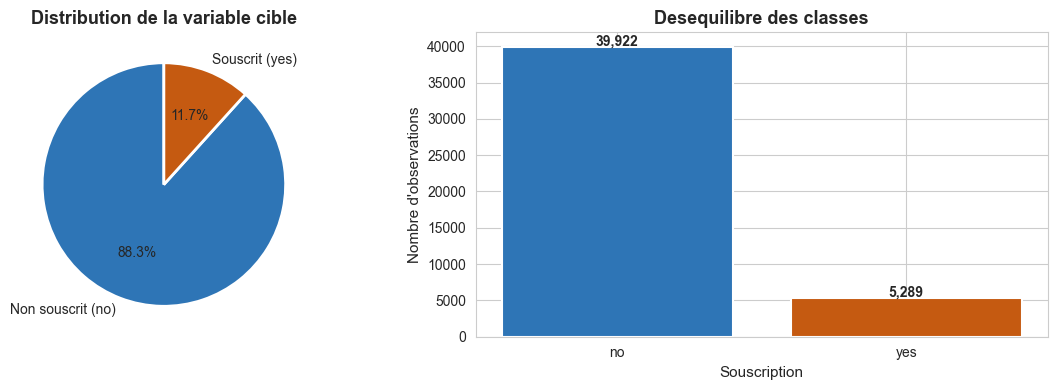

Taux de souscription : 11.7%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['souscription'].value_counts()
colors = ['#2E75B6', '#C55A11']

axes[0].pie(counts, labels=['Non souscrit (no)', 'Souscrit (yes)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribution de la variable cible', fontweight='bold')

axes[1].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Souscription')
axes[1].set_ylabel("Nombre d'observations")
axes[1].set_title('Desequilibre des classes', fontweight='bold')
for i, (k, v) in enumerate(counts.items()):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Taux de souscription : {(df['souscription']=='yes').mean()*100:.1f}%")

### 3.2 Analyse bivariee des variables numeriques par classe

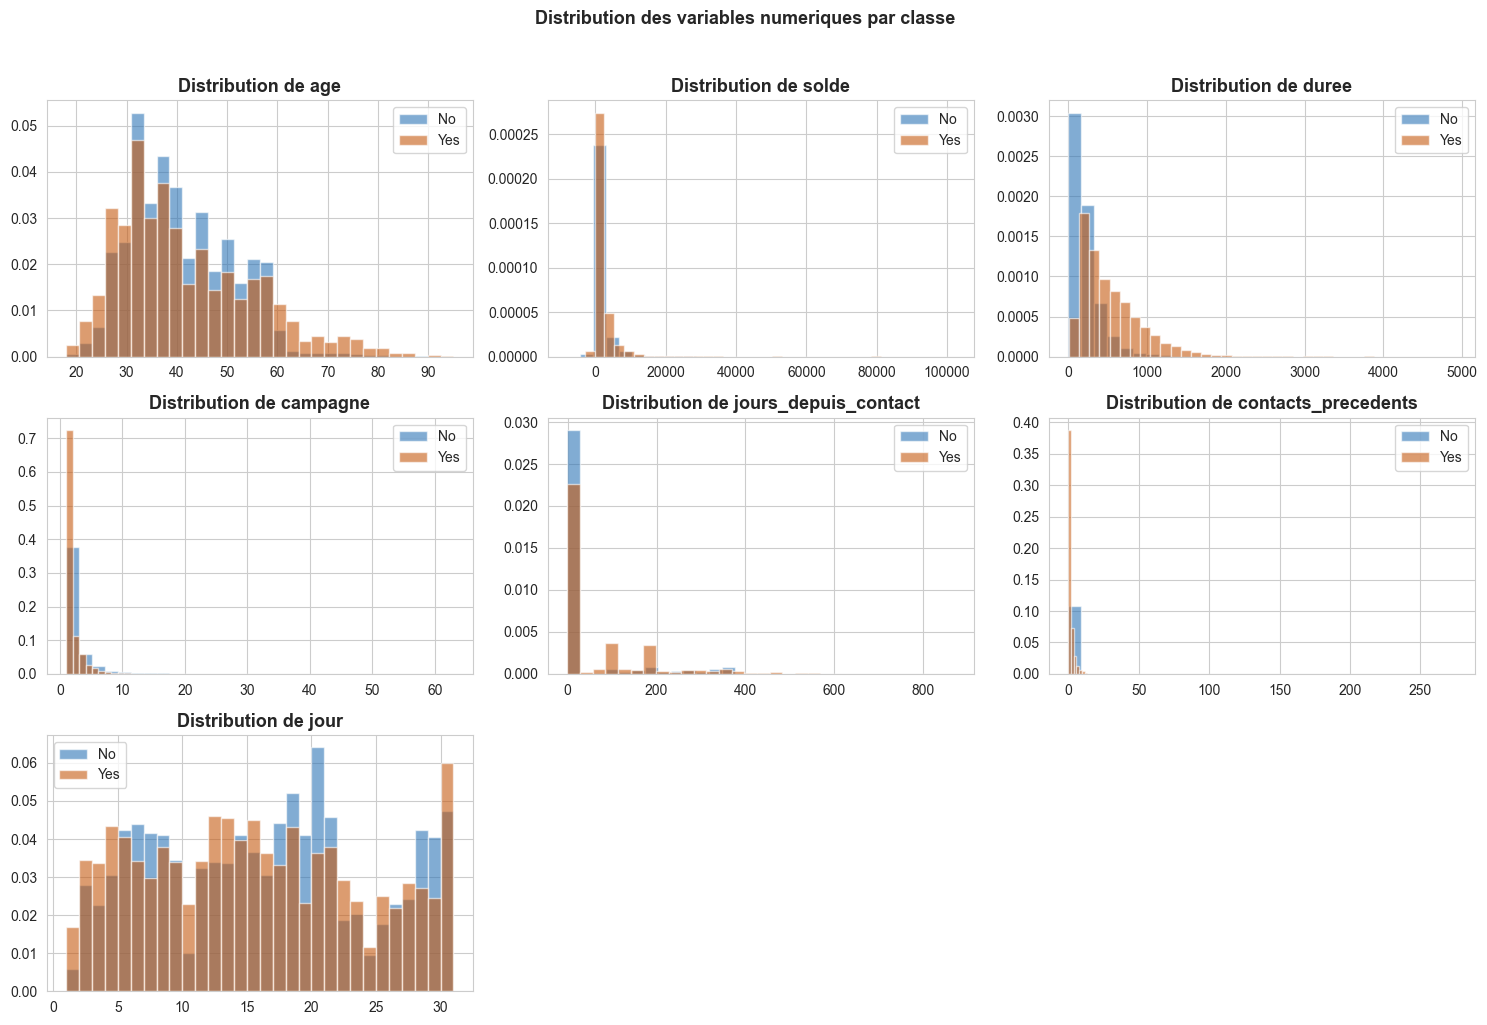

In [7]:
# Note : 'duree' est incluse ici pour l'EDA uniquement.
# Elle sera supprimee avant la modelisation (data leakage).
num_cols_eda = ['age', 'solde', 'duree', 'campagne', 'jours_depuis_contact', 'contacts_precedents', 'jour']
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    df[df['souscription'] == 'no'][col].hist(
        ax=axes[i], alpha=0.6, color='#2E75B6', label='No', bins=30, density=True)
    df[df['souscription'] == 'yes'][col].hist(
        ax=axes[i], alpha=0.6, color='#C55A11', label='Yes', bins=30, density=True)
    axes[i].set_title(f'Distribution de {col}', fontweight='bold')
    axes[i].legend()

for j in range(len(num_cols_eda), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution des variables numeriques par classe', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('num_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

Voici l'interprétation détaillée de chaque distribution :



**1. Distribution de l'âge**

La masse se concentre entre 25 et 55 ans. Les refus  dominent la tranche active 30–50 ans — ces clients ont des charges financières élevées. Les souscriptions  sont relativement plus présentes avant 30 ans et après 55 ans, confirmant que les jeunes et les pré-retraités sont plus réceptifs aux produits d'épargne.



**2. Distribution de solde**

Distribution très concentrée autour de 0–5 000 €, avec une longue queue vers 100 000 €. Les deux classes se superposent presque parfaitement, ce qui indique que le solde seul ne discrimine pas bien. Cependant, les clients Yes ont une légère tendance à avoir des soldes légèrement plus élevés — cohérent avec son importance de 9.9% dans le Random Forest.



**3. Distribution de durée**

C'est la distribution la plus discriminante du dataset. Les appels courts (< 200 sec) sont massivement associés aux refus (bleu très dominant). À partir de 500–1000 secondes, la proportion orange (Yes) augmente nettement. Un appel long signale un client engagé et intéressé — ce qui explique pourquoi `durée` est la variable la plus importante (45.8%).



**4. Distribution de campagne (nombre de contacts)**

Extrêmement concentrée sur 1–3 contacts. La grande majorité des clients, qu'ils souscrivent ou non, ont été contactés 1 à 2 fois. Au-delà de 5 contacts, la densité chute fortement et les refus dominent très nettement — c'est le signal classique de **fatigue marketing** : relancer trop souvent un client diminue sa probabilité de souscription.



**5. Distribution de jours depuis contact (pdays)**


La très grande majorité des observations est à 0 (jamais contactés avant, codé -1 puis remappé). Seule une petite fraction a été recontactée. Parmi ceux-ci, les clients Yes montrent une distribution légèrement plus étalée (jusqu'à 400 jours), suggérant que les clients déjà engagés par le passé restent joignables même longtemps après. Cette variable a une importance de 5% mais devient très puissante combinée à `poutcome`.



**6. Distribution de contacts précédents (previous)**

Encore plus concentrée que `pdays` : 80–90% des clients ont 0 contact précédent. Parmi ceux qui en ont eu, les clients Yes sont proportionnellement plus nombreux dès 1–2 contacts précédents. Cela confirme que **les clients déjà engagés lors d'une campagne antérieure sont de meilleurs prospects**.



**7. Distribution de jour **

Distribution relativement uniforme entre le 1er et le 31, avec une légère hausse en fin de mois (jours 20–31). Les deux classes se répartissent de manière similaire tout au long du mois — cette variable a donc peu de pouvoir discriminant direct, mais capture peut-être des effets indirects (ex : relances en fin de mois).






**Synthèse générale**

| Variable | Pouvoir discriminant | Signal principal |
|----------|---------------------|-----------------|
| duree | Très élevé | Long appel → souscription |
| campagne | Moyen | Peu de contacts → meilleur |
| contacts_précédents | Moyen | Contact passé → signal positif |
| age | Faible-moyen | < 30 et > 55 ans favorables |
| solde | Faible | Solde élevé légèrement positif |
|de jours depuis contact | Faible | Surtout utile combiné à poutcome |
| jour | Très faible | Pas de signal clair |


### 3.3 Test de Welch (t-test) — Variables numeriques vs Cible

Nombre de clients — No : 39,922  |  Yes : 5,289

   Moyennes par classe
Variable                   Moy. NO  Moy. YES
---------------------------------------------
age                          40.84     41.67
solde                      1303.71   1804.27
campagne                      2.85      2.14
jours_depuis_contact         36.42     68.70
contacts_precedents           0.50      1.17
jour                         15.89     15.16


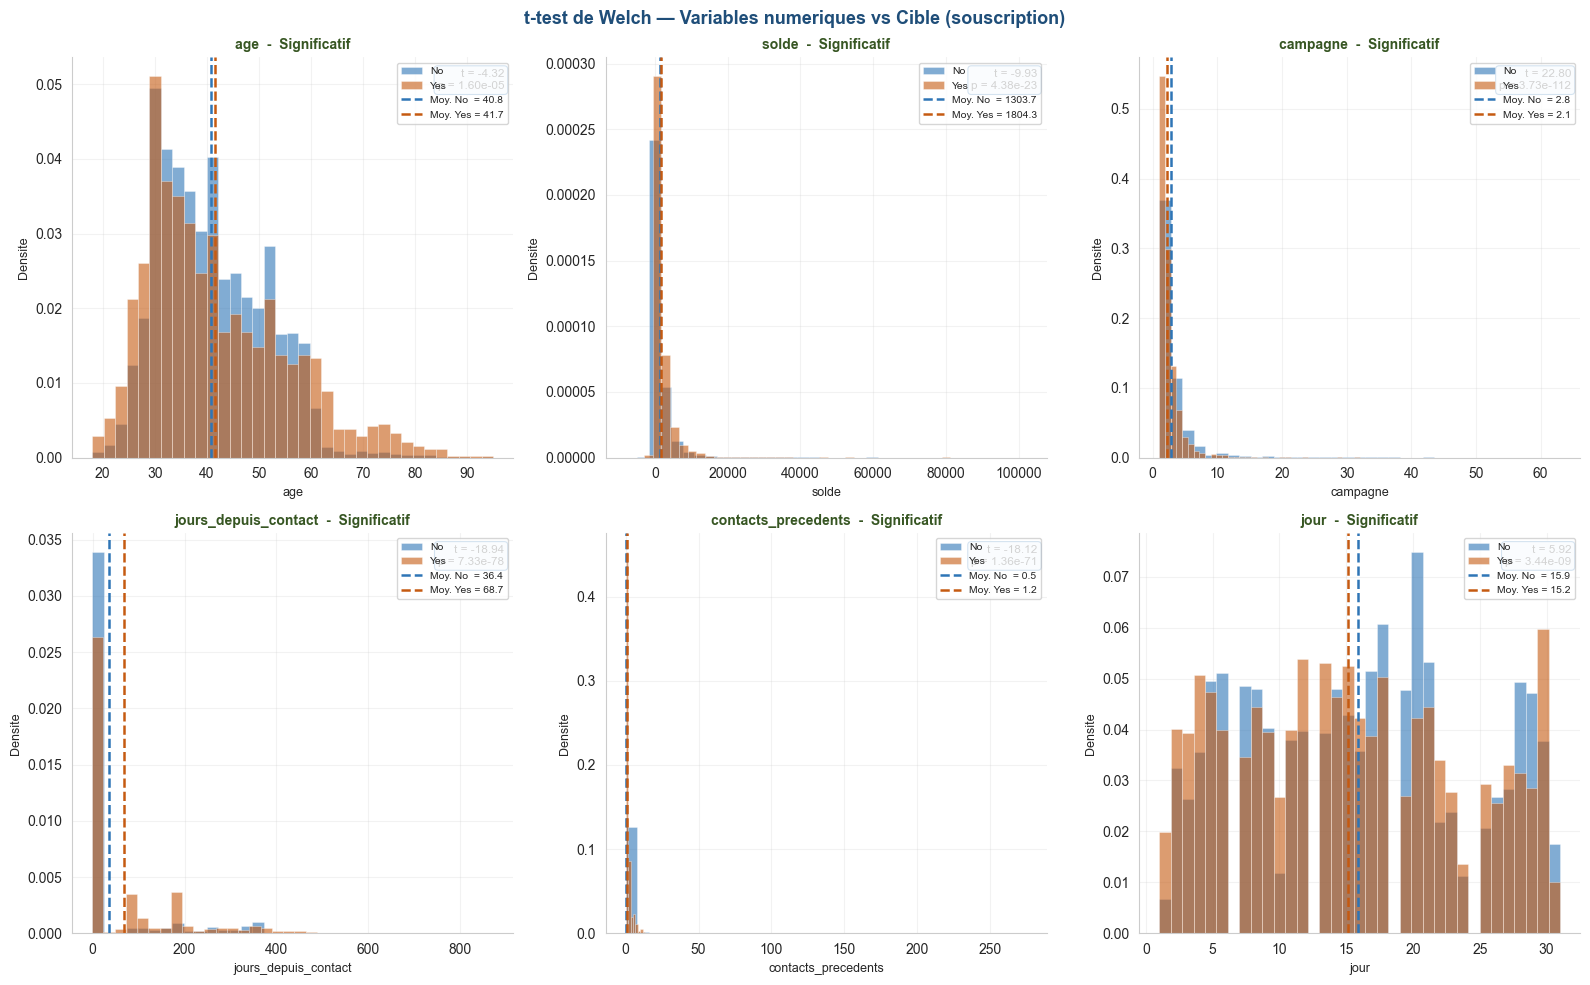

In [8]:
from scipy import stats

num_cols_test = ['age', 'solde', 'campagne', 'jours_depuis_contact', 'contacts_precedents', 'jour']
group_no  = df[df['souscription'] == 'no']
group_yes = df[df['souscription'] == 'yes']

print(f"Nombre de clients — No : {len(group_no):,}  |  Yes : {len(group_yes):,}")
print("\n" + "=" * 45)
print("   Moyennes par classe")
print("=" * 45)
print(f"{'Variable':<25} {'Moy. NO':>8} {'Moy. YES':>9}")
print("-" * 45)

resultats = {}
for col in num_cols_test:
    no_vals  = group_no[col].dropna()
    yes_vals = group_yes[col].dropna()
    t_stat, p_val = stats.ttest_ind(no_vals, yes_vals, equal_var=False)
    resultats[col] = {
        'moy_no': no_vals.mean(), 'moy_yes': yes_vals.mean(),
        'std_no': no_vals.std(),  'std_yes': yes_vals.std(),
        't_stat': t_stat, 'p_val': p_val, 'sig': p_val < 0.05,
    }
    print(f"{col:<25} {no_vals.mean():>8.2f} {yes_vals.mean():>9.2f}")
print("=" * 45)

COLORS = {'no': '#2E75B6', 'yes': '#C55A11'}
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols_test):
    ax = axes[i]
    r  = resultats[col]
    no_vals  = group_no[col].dropna()
    yes_vals = group_yes[col].dropna()
    ax.hist(no_vals,  bins=35, density=True, alpha=0.60, color=COLORS['no'],
            label='No',  edgecolor='white', linewidth=0.4)
    ax.hist(yes_vals, bins=35, density=True, alpha=0.60, color=COLORS['yes'],
            label='Yes', edgecolor='white', linewidth=0.4)
    ax.axvline(r['moy_no'],  color=COLORS['no'],  linestyle='--', linewidth=1.8,
               label=f"Moy. No  = {r['moy_no']:.1f}")
    ax.axvline(r['moy_yes'], color=COLORS['yes'], linestyle='--', linewidth=1.8,
               label=f"Moy. Yes = {r['moy_yes']:.1f}")
    sig_str     = "Significatif" if r['sig'] else "Non significatif"
    color_title = '#375623' if r['sig'] else '#C00000'
    ax.set_title(f"{col}  -  {sig_str}", fontsize=10, fontweight='bold', color=color_title)
    ax.text(0.98, 0.97, f"t = {r['t_stat']:.2f}\np = {r['p_val']:.2e}",
            transform=ax.transAxes, fontsize=8.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#E8F4FD' if r['sig'] else '#FFF0F0',
                      edgecolor=COLORS['no'] if r['sig'] else COLORS['yes'],
                      linewidth=0.8))
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel("Densite", fontsize=9)
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("t-test de Welch — Variables numeriques vs Cible (souscription)",
             fontsize=13, fontweight='bold', color='#1F4E79')
plt.tight_layout()
plt.savefig('ttest_histogrammes.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.4 Taux de souscription par variable categorielle

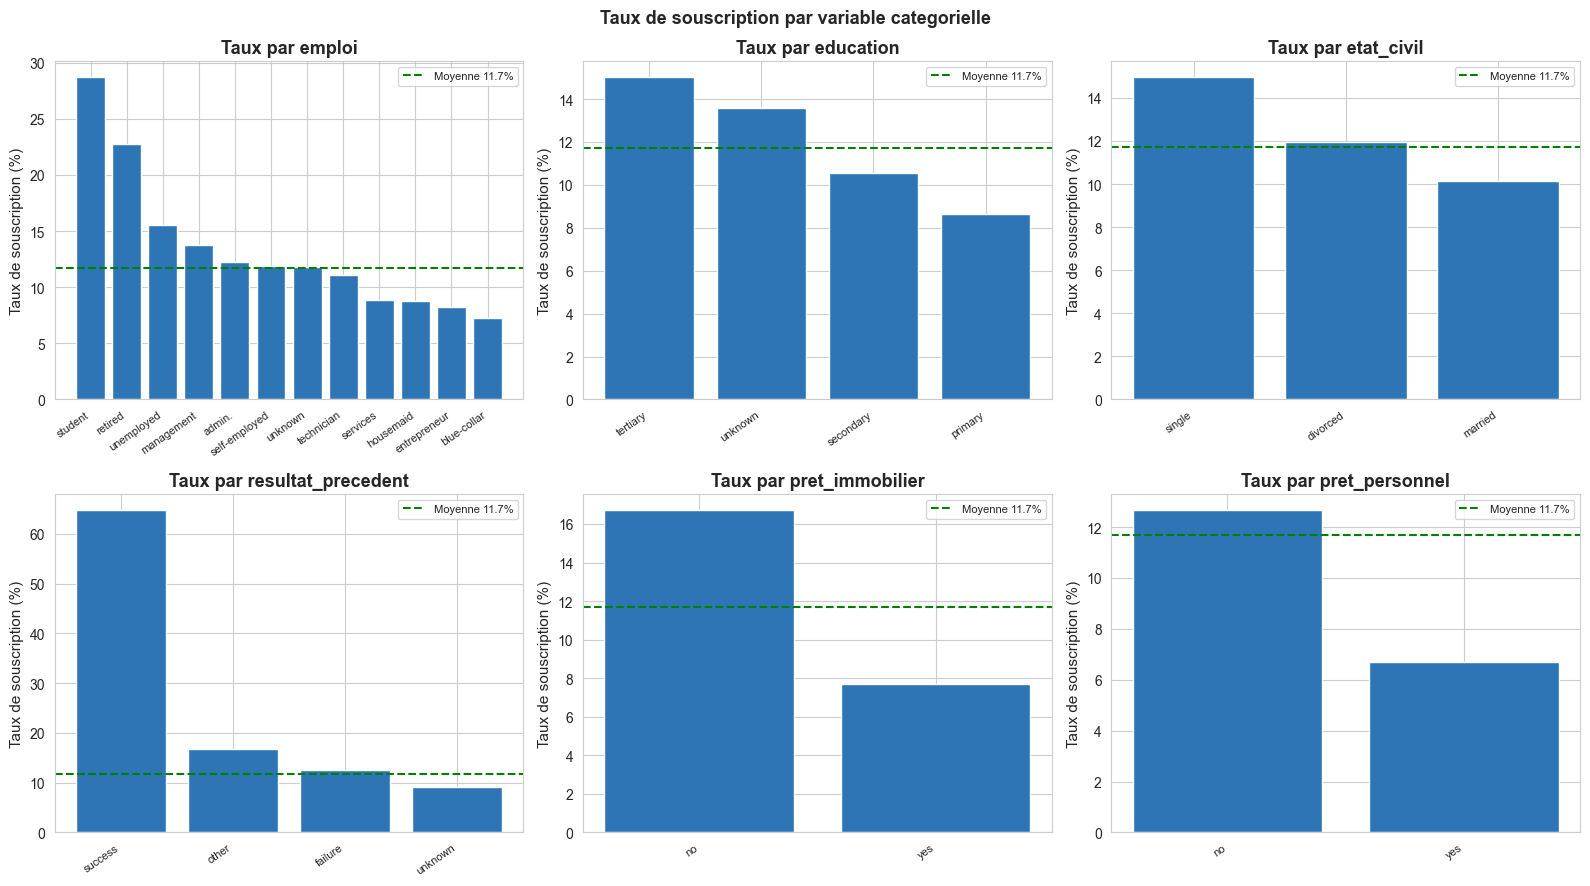

In [10]:
cat_cols_plot = ['emploi', 'education', 'etat_civil',
                'resultat_precedent', 'pret_immobilier', 'pret_personnel']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
moy_globale = (df['souscription'] == 'yes').mean() * 100

for i, col in enumerate(cat_cols_plot):
    rate = df.groupby(col)['souscription'].apply(
        lambda x: (x == 'yes').mean() * 100
    ).sort_values(ascending=False)
    axes[i].bar(range(len(rate)), rate.values, color='#2E75B6', edgecolor='white')
    axes[i].set_xticks(range(len(rate)))
    axes[i].set_xticklabels(rate.index, rotation=35, ha='right', fontsize=8)
    axes[i].set_ylabel('Taux de souscription (%)')
    axes[i].set_title(f'Taux par {col}', fontweight='bold')
    axes[i].axhline(y=moy_globale, color='#008000', linestyle='--',
                    linewidth=1.5, label=f'Moyenne {moy_globale:.1f}%')
    axes[i].legend(fontsize=8)

plt.suptitle('Taux de souscription par variable categorielle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cat_rates.png', dpi=120, bbox_inches='tight')
plt.show()



### Interprétation des Graphiques - Taux de Souscription par Variable Catégorique

Ces graphiques montrent le pourcentage de clients qui ont souscrit au dépôt à terme, pour chaque catégorie. La ligne pointillée orange représente la moyenne globale (11.7%).

#### 1. Taux par Emploi
Observations :
- Student (Etudiant) : 28% - Le taux le plus élevé
- Retired (Retraité) : 22% - Deuxième plus haut
- Management (Cadre) : 15% - Au-dessus de la moyenne
- Entrepreneur : 13% - Proche de la moyenne
- Admin : 12% - Proche de la moyenne
- Technician, Services, Unknown : 11% - Proche de la moyenne
- Unemployed, Housemaid, Self-employed, Blue-collar : 7-10% - Sous la moyenne

Conclusion : Les étudiants et retraités sont beaucoup plus susceptibles de souscrire. Les ouvriers et sans-emploi ont les taux les plus bas.

#### 2. Taux par Éducation

Observations :
- Tertiary (Études supérieures) : 15% - Le plus haut
- Unknown (Inconnu) : 13% - Deuxième
- Secondary (Secondaire) : 10% - Sous la moyenne
- Primary (Primaire) : 8% - Le plus bas

Conclusion : Les clients ayant une éducation supérieure sont plus susceptibles de souscrire. Le niveau d'éducation a un impact réel : plus l'éducation est élevée, plus le taux de souscription augmente.

## 3. Taux par État Civil
Observations :
- Single (Célibataire) : 15% - Le plus haut
- Divorced (Divorcé) : 12% - Proche de la moyenne
- Married (Marié) : 10% - Sous la moyenne

Conclusion : Les célibataires sont plus susceptibles de souscrire que les personnes mariées. La différence est modérée mais notable.

## 4. Taux par Résultat Précédent

Observations :
- Success (Succès) : 64% - ÉNORMÉMENT plus élevé
- Other : 15% - Proche de la moyenne
- Failure (Échec) : 11% - Proche de la moyenne
- Unknown : 6% - Le plus bas

Conclusion : SIGNAL TRÈS IMPORTANT. Si un client a déjà souscrit à une campagne précédente, il a 64% de chances de souscrire à nouveau. C'est la variable la plus prédictive. Les clients jamais contactés (Unknown) ont le taux le plus bas.

## 5. Taux par Prêt Immobilier
Observations :
- No (Pas de prêt immobilier) : 16% - Au-dessus de la moyenne
- Yes (A un prêt immobilier) : 8% - Sous la moyenne

Conclusion : Contre-intuitif : les clients SANS prêt immobilier sont plus susceptibles de souscrire. Les clients avec un prêt immobilier (endettés) souscrivent moins. Cela suggère que les clients libres de dettes sont plus disposés à placer leur argent.

## 6. Taux par Prêt Personnel
Observations :
- No (Pas de prêt personnel) : 12% - Légèrement au-dessus de la moyenne
- Yes (A un prêt personnel) : 6% - Bien en-dessous de la moyenne

Conclusion : Les clients avec un prêt personnel sont 2 fois moins susceptibles de souscrire. L'endettement personnel réduit fortement la propension à investir dans un dépôt à terme.



### 3.5 Heatmap

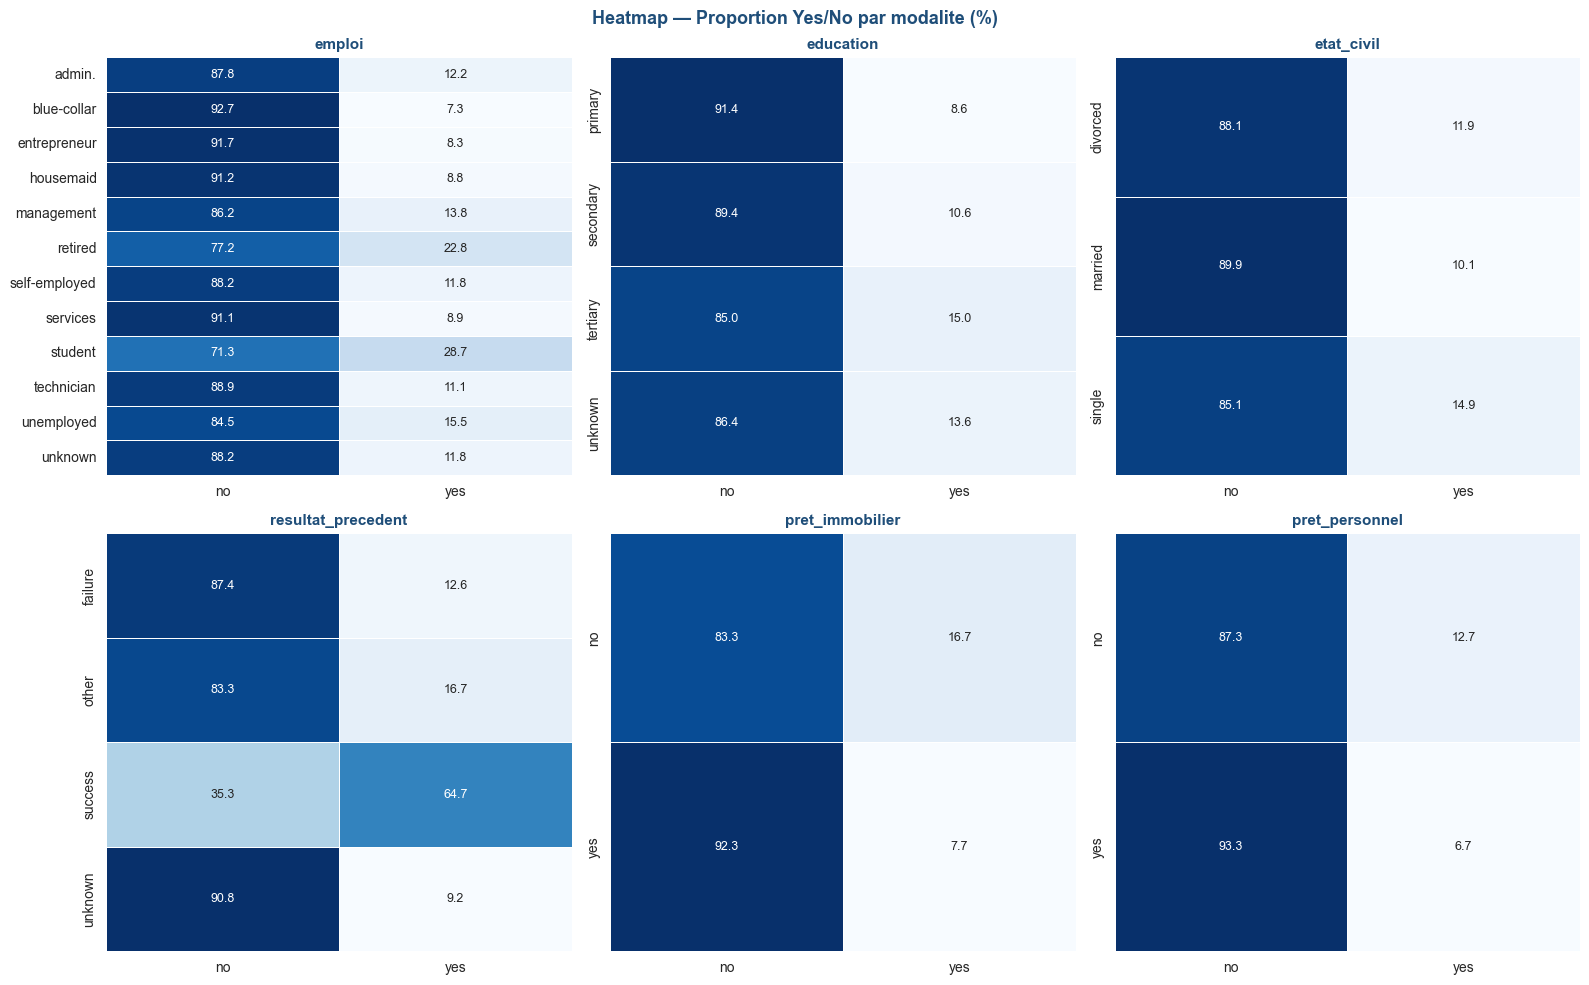

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    ax = axes[i]
    table = pd.crosstab(df[col], df['souscription'], normalize='index') * 100
    sns.heatmap(table, annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, linecolor='white', cbar=False, ax=ax,
                annot_kws={'size': 9})
    ax.set_title(col, fontsize=11, fontweight='bold', color='#1F4E79')
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Heatmap — Proportion Yes/No par modalite (%)',
             fontsize=13, fontweight='bold', color='#1F4E79')
plt.tight_layout()
plt.savefig('heatmap_categories.png', dpi=150, bbox_inches='tight')
plt.show()



#### Interpretation Heatmap Proportion Yes/No par modalité

Confirme visuellement les résultats précédents avec les proportions exactes :

- **Emploi** : student (28.7% Yes) et retired (22.8% Yes) se détachent clairement en bleu clair (plus de Yes).
- **Éducation** : tertiaire = 15% Yes, primaire = 8.6% Yes.
- **État civil** : single = 14.9% Yes, le plus élevé.
- **Résultat précédent** : la cellule **"success / Yes" (64.7%)** ressort en bleu très clair — c'est visuellement la modalité la plus prédictive de tout le dataset.
- **Prêts** : avoir un prêt (immobilier ou personnel) réduit fortement la probabilité de souscription.



### 3.5 Matrice de correlation des variables numeriques

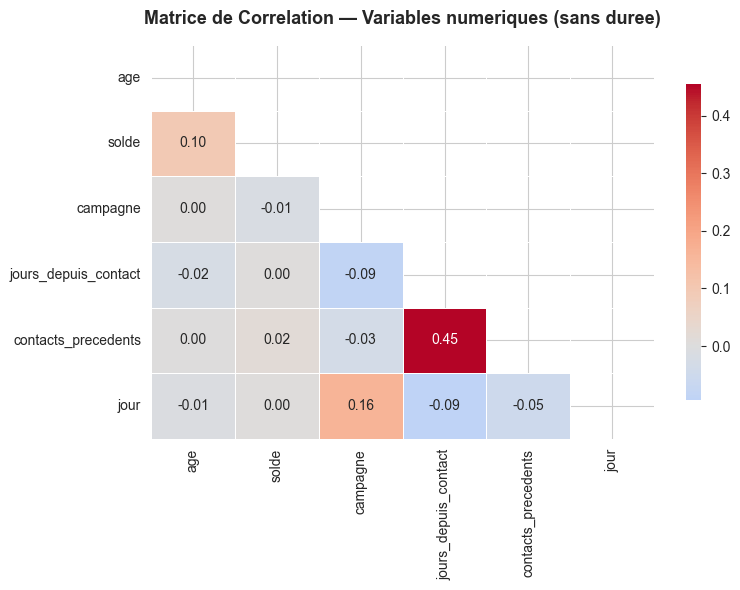

In [11]:
df_num = df[['age', 'solde', 'campagne', 'jours_depuis_contact',
              'contacts_precedents', 'jour']].copy()
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de Correlation — Variables numeriques (sans duree)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()



###   Interpretation  de la matrice de correlation

Les corrélations entre variables numériques sont **globalement très faibles**, ce qui est une bonne nouvelle (pas de multicolinéarité problématique) :

- **jours_depuis_contact ↔ contacts_précédents : 0.45** — la seule corrélation modérée. Les clients recontactés longtemps après ont tendance à avoir eu plus de contacts antérieurs, logique dans une stratégie de fidélisation.
- **campagne ↔ jour : 0.16** — très faible, quasi-négligeable.
- Toutes les autres corrélations sont proches de **0**, confirmant l'indépendance des variables numériques entre elles.


## 4. Preparation des Donnees

### Etapes :
1. Suppression de `duree` (data leakage — variable inconnue avant l'appel)
2. Encodage des variables categorielles avec sauvegarde des encodeurs
3. Encodage ordinal de `type_contact` et encodage cyclique sin/cos de `mois`
4. Division Train / Test (80% / 20%, stratifiee)
5. Normalisation StandardScaler (fit uniquement sur train)
6. Gestion du desequilibre avec SMOTE (uniquement sur train)

### 4.1 Suppression de `duree` — data leakage

La variable `duree` (duree de l'appel en secondes) n'est connue qu'apres l'appel telephonique.
Un modele de scoring reel ne peut pas l'utiliser comme feature d'entree.
La garder produirait un modele inutilisable en production (AUC artificiellement eleve).

In [12]:
df_enc = df.copy()
df_enc = df_enc.drop(columns=['duree'])

print("'duree' supprimee — data leakage evite")
print(f"Features restantes : {df_enc.shape[1] - 1}")
print(f"Colonnes : {list(df_enc.columns)}")

'duree' supprimee — data leakage evite
Features restantes : 15
Colonnes : ['age', 'emploi', 'etat_civil', 'education', 'credit_defaut', 'solde', 'pret_immobilier', 'pret_personnel', 'type_contact', 'jour', 'mois', 'campagne', 'jours_depuis_contact', 'contacts_precedents', 'resultat_precedent', 'souscription']


### 4.2 Encodage des variables categorielles

**LabelEncoder** pour les colonnes categorielles avec sauvegarde des encodeurs pour la production.
**Encodage ordinal** pour `type_contact` (unknown=1 < telephone=2 < cellular=3).
**Encodage cyclique sin/cos** pour `mois` : les mois forment un cycle (decembre proche de janvier).

In [13]:
cat_cols = ['emploi', 'education', 'etat_civil',
            'resultat_precedent', 'pret_immobilier', 'pret_personnel', 'credit_defaut']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

df_enc['souscription'] = (df_enc['souscription'] == 'yes').astype(int)

mapping_contact = {'unknown': 1, 'telephone': 2, 'cellular': 3}
df_enc['type_contact'] = df_enc['type_contact'].map(mapping_contact)

mapping_mois = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
df_enc['mois'] = df_enc['mois'].str.lower().str.strip().map(mapping_mois)
df_enc['mois_sin'] = np.sin(2 * np.pi * df_enc['mois'] / 12)
df_enc['mois_cos'] = np.cos(2 * np.pi * df_enc['mois'] / 12)
df_enc = df_enc.drop(columns=['mois'])

print("Encodage termine")
print(f"Distribution de la cible encodee :")
print(df_enc['souscription'].value_counts())
print(f"Taux positif : {df_enc['souscription'].mean()*100:.1f}%")
print(f"Valeurs manquantes apres encodage : {df_enc.isna().sum().sum()}")

Encodage termine
Distribution de la cible encodee :
souscription
0    39922
1     5289
Name: count, dtype: int64
Taux positif : 11.7%
Valeurs manquantes apres encodage : 0


In [14]:
df_enc.head(5)

,age,emploi,etat_civil,education,credit_defaut,solde,pret_immobilier,pret_personnel,type_contact,jour,campagne,jours_depuis_contact,contacts_precedents,resultat_precedent,souscription,mois_sin,mois_cos
0,58,4,1,2,0,2143,1,0,1,5,1,-1,0,3,0,0.5,-0.866025
1,44,9,2,1,0,29,1,0,1,5,1,-1,0,3,0,0.5,-0.866025
2,33,2,1,1,0,2,1,1,1,5,1,-1,0,3,0,0.5,-0.866025
3,47,1,1,3,0,1506,1,0,1,5,1,-1,0,3,0,0.5,-0.866025
4,33,11,2,3,0,1,0,0,1,5,1,-1,0,3,0,0.5,-0.866025


### 4.3 Division Train / Test

In [20]:
X = df_enc.drop('souscription', axis=1)
y = df_enc['souscription']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f"Division effectuee")
print(f"   Train : {X_train.shape[0]:,} observations ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  : {X_test.shape[0]:,} observations ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"   Features : {X_train.shape[1]}")
print(f"   Taux positif train : {y_train.mean()*100:.1f}%")
print(f"   Taux positif test  : {y_test.mean()*100:.1f}%")

Division effectuee
   Train : 36,168 observations (80%)
   Test  : 9,043 observations (20%)
   Features : 16
   Taux positif train : 11.7%
   Taux positif test  : 11.7%


### 4.4 Gestion du desequilibre — SMOTE

Le dataset contient ~88% de "no" et ~12% de "yes".
**SMOTE** genere des exemples synthetiques de la classe minoritaire
uniquement sur le jeu d'entrainement, ce qui preserve l'integrite du test.

SMOTE applique
   Avant SMOTE — No: 31,937  |  Yes: 4,231
   Apres SMOTE — No: 31,937  |  Yes: 31,937


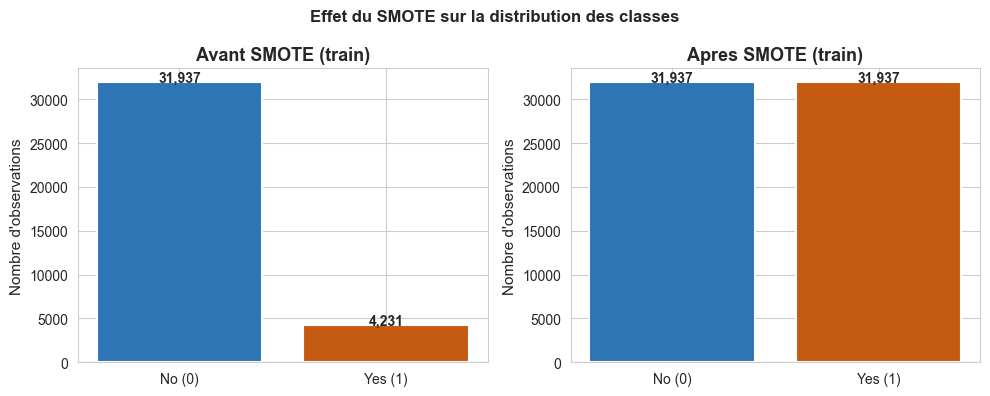

In [21]:
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print("SMOTE applique")
print(f"   Avant SMOTE — No: {(y_train==0).sum():,}  |  Yes: {(y_train==1).sum():,}")
print(f"   Apres SMOTE — No: {(y_train_sm==0).sum():,}  |  Yes: {(y_train_sm==1).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_plot, title) in zip(axes, [
    (y_train,    "Avant SMOTE (train)"),
    (y_train_sm, "Apres SMOTE (train)")
]):
    counts = pd.Series(y_plot).value_counts()
    ax.bar(['No (0)', 'Yes (1)'], counts.values,
           color=['#2E75B6', '#C55A11'], edgecolor='white', linewidth=1.5)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel("Nombre d'observations")

plt.suptitle("Effet du SMOTE sur la distribution des classes", fontweight='bold')
plt.tight_layout()
plt.savefig('smote_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretation de l effet de SMOTE

Ce graphique illustre le **rééquilibrage des classes** avant modélisation :

- **Avant SMOTE** : forte déséquilibre — 31 937 "No" contre seulement 4 231 "Yes" (~88% vs ~12%). Un modèle naïf prédirait toujours "No" et serait précis à 88% sans rien apprendre.
- **Après SMOTE** : les deux classes sont parfaitement **équilibrées à 31 937 chacune**. Le SMOTE a généré des exemples synthétiques de la classe minoritaire ("Yes") pour corriger ce déséquilibre et permettre aux modèles d'apprendre correctement les deux classes.




## 5. Implementation et Comparaison des Classificateurs

| # | Modele | Type | Normalisation requise |
|---|--------|------|-----------------------|
| 1 | Logistic Regression | Lineaire | necessite |
| 2 | Decision Tree | Arbre | ne necessite pas |
| 3 | Random Forest | Ensemble (Bagging) | ne necessite pas |
| 4 | Gradient Boosting | Ensemble (Boosting) | ne necessite pas |
| 5 | AdaBoost | Ensemble (Boosting) | ne necessite pas |
| 6 | Naive Bayes | Probabiliste | necessite |
| 7 | K-Nearest Neighbors | Instance-based | necessite |
| 8 | MLP (64-32) | Reseau de neurones | necessite |
| 9 | MLP (128-64-32) | Reseau de neurones | necessite |

In [22]:
classifiers = {
    'Logistic Regression': (
        LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
        True
    ),
    'Decision Tree': (
        DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
        False
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               n_jobs=-1, random_state=42),
        False
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                   max_depth=3, random_state=42),
        False
    ),
    'AdaBoost': (
        AdaBoostClassifier(n_estimators=100, random_state=42),
        False
    ),
    'Naive Bayes': (
        GaussianNB(),
        True
    ),
    'KNN (k=11)': (
        KNeighborsClassifier(n_neighbors=11, n_jobs=-1),
        True
    ),
    'MLP (64-32)': (
        MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                      solver='adam', max_iter=300, early_stopping=True,
                      validation_fraction=0.1, random_state=42),
        True
    ),
    'MLP (128-64-32)': (
        MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                      solver='adam', alpha=0.001, learning_rate='adaptive',
                      max_iter=500, early_stopping=True, validation_fraction=0.1,
                      n_iter_no_change=20, random_state=42),
        True
    ),
}

print(f"{len(classifiers)} modeles definis et prets a l'entrainement")

9 modeles definis et prets a l'entrainement


# 5.1 Entrainement des modeles 

In [23]:
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("=" * 70)
print(f"{'Modele':<22} | {'CV AUC':>8} | {'Test AUC':>9} | {'Accuracy':>9} | {'F1':>7}")
print("=" * 70)

for name, (clf, use_sc) in classifiers.items():
    Xtr = X_train_sm if use_sc else X_train
    Ytr = y_train_sm if use_sc else y_train
    Xte = X_test_sc  if use_sc else X_test

    cv_auc = cross_val_score(clf, Xtr, Ytr, cv=cv, scoring='roc_auc')
    clf.fit(Xtr, Ytr)
    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)

    results[name] = {
        'clf': clf, 'use_sc': use_sc,
        'cv_auc': cv_auc.mean(), 'cv_std': cv_auc.std(),
        'test_acc': acc, 'test_auc': auc, 'test_f1': f1,
        'y_prob': y_prob, 'y_pred': y_pred,
    }

    flag = " <-- meilleur" if auc == max([v.get('test_auc', 0) for v in results.values()]) else ""
    print(f"{name:<22} | {cv_auc.mean():.4f}+/-{cv_auc.std():.3f} | {auc:.4f}    | {acc:.4f}   | {f1:.4f}{flag}")

print("=" * 70)
print("Entrainement termine !")

Modele                 |   CV AUC |  Test AUC |  Accuracy |      F1
Logistic Regression    | 0.7320+/-0.005 | 0.7332    | 0.6404   | 0.3165 <-- meilleur
Decision Tree          | 0.7460+/-0.007 | 0.7589    | 0.8090   | 0.4063 <-- meilleur
Random Forest          | 0.7832+/-0.005 | 0.7932    | 0.8940   | 0.3174 <-- meilleur
Gradient Boosting      | 0.7901+/-0.005 | 0.7983    | 0.8932   | 0.2897 <-- meilleur
AdaBoost               | 0.7736+/-0.003 | 0.7824    | 0.8920   | 0.2638
Naive Bayes            | 0.7124+/-0.004 | 0.7120    | 0.5482   | 0.2901
KNN (k=11)             | 0.9172+/-0.001 | 0.7255    | 0.7170   | 0.3358
MLP (64-32)            | 0.8849+/-0.006 | 0.7367    | 0.7775   | 0.3685
MLP (128-64-32)        | 0.9311+/-0.003 | 0.6838    | 0.7924   | 0.3081
Entrainement termine !


# Formules des métriques 

## Blocs de base : Matrice de confusion

| | Prédit : Yes (1) | Prédit : No (0) |
|---|---|---|
| **Réel : Yes (1)** | TP — Vrais Positifs | FN — Faux Négatifs |
| **Réel : No (0)** | FP — Faux Positifs | TN — Vrais Négatifs |

> **TP** = Vrais Positifs · **TN** = Vrais Négatifs · **FP** = Faux Positifs · **FN** = Faux Négatifs



## 1. Accuracy (Exactitude)

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Pourcentage de prédictions correctes sur toutes les observations.
Trompeuse avec des classes déséquilibrées.



## 2. Précision (Precision)

$$\text{Précision} = \frac{TP}{TP + FP}$$

Parmi tous les clients prédits "Yes", combien l'étaient vraiment ?
→ Minimise les **faux positifs** (contacts inutiles).


## 3. Rappel (Recall / Sensibilité)

$$\text{Rappel} = \frac{TP}{TP + FN}$$

Parmi tous les vrais souscripteurs, combien le modèle en a-t-il détectés ?
→ Minimise les **faux négatifs** (clients manqués).



## 4. F1-Score

$$\text{F1} = 2 \times \frac{\text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

Moyenne harmonique entre Précision et Rappel.
Pénalise les modèles qui sacrifient l'un pour l'autre.


## 5. AUC-ROC

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d\text{FPR}$$

Avec :

$$\text{TPR} = \frac{TP}{TP + FN} \qquad \text{FPR} = \frac{FP}{FP + TN}$$

Aire sous la courbe ROC (TPR vs FPR à tous les seuils possibles). TPR = Taux de vrais positifs FPR = Taux de faux positifs



## 6. CV AUC — Cross-Validation (k=5 plis)

$$\overline{\text{AUC}}_{CV} = \frac{1}{k} \sum_{i=1}^{k} \text{AUC}_i$$

$$\sigma_{CV} = \sqrt{\frac{1}{k} \sum_{i=1}^{k} \left(\text{AUC}_i - \overline{\text{AUC}}_{CV}\right)^2}$$

Affiché dans le tableau sous la forme : `CV_AUC ± std`

Un **std faible** indique un modèle stable entre les plis.



## Résumé des métriques — Tableau comparatif

| Métrique | Formule courte | Ce qu'elle mesure | Limite principale |
|---|---|---|---|
| Accuracy | (TP+TN) / Total | % bonnes prédictions | Biaisée si classes déséquilibrées |
| Précision | TP / (TP+FP) | Qualité des "Yes" prédits | Ignore les FN |
| Rappel | TP / (TP+FN) | Détection des vrais "Yes" | Ignore les FP |
| F1-Score | 2·Précision·Rappel / (P+R) | Équilibre P/R | Sensible au seuil (0.5) |
| AUC-ROC | Aire sous courbe TPR/FPR | Discrimination générale | Insensible au seuil |
| CV AUC ± std | Moyenne sur k plis | Stabilité du modèle | Risque de data leakage si SMOTE avant CV |



## Relation entre les métriques

```
Matrice de confusion
       ┌──────────────────────────────────────┐
       │  TP   FN   →  Rappel  = TP/(TP+FN)  │
       │  FP   TN   →  Précision = TP/(TP+FP) │
       └──────────────────────────────────────┘
                ↓
           F1-Score  (combine Précision + Rappel)
                ↓
      AUC-ROC  (évalue à tous les seuils possibles)
                ↓
      CV AUC   (stabilité sur k plis)
```



> **Note projet :** Dans un contexte de campagne marketing bancaire, le **Rappel** est la métrique
> métier la plus importante — rater un souscripteur potentiel coûte plus cher que contacter
> un non-souscripteur. Privilégier l'**AUC-ROC** comme métrique principale et abaisser
> le seuil de décision (ex. 0.3 au lieu de 0.5) pour maximiser le rappel.


## 6. Ensemble de Modeles — Voting Classifier

Le **Voting Classifier (soft)** combine plusieurs modeles en calculant la moyenne
de leurs probabilites predites. Il exploite la complementarite des modeles pour
reduire biais et variance simultanement.

In [24]:
voting = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                       n_jobs=-1, random_state=42)),
        ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('ada', AdaBoostClassifier(n_estimators=100, random_state=42)),
        ('lr',  LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)),
    ],
    voting='soft'
)

print("Entrainement du Voting Ensemble...")
voting.fit(X_train, y_train)

yv_pred = voting.predict(X_test)
yv_prob = voting.predict_proba(X_test)[:, 1]

acc_v = accuracy_score(y_test, yv_pred)
auc_v = roc_auc_score(y_test, yv_prob)
f1_v  = f1_score(y_test, yv_pred)

# CORRECTION : calcul de la validation croisee du Voting Ensemble
cv_auc_v = cross_val_score(voting, X_train, y_train, cv=cv, scoring='roc_auc')

results['Voting Ensemble'] = {
    'clf': voting, 'use_sc': False,
    'cv_auc': cv_auc_v.mean(), 'cv_std': cv_auc_v.std(),
    'test_acc': acc_v, 'test_auc': auc_v, 'test_f1': f1_v,
    'y_prob': yv_prob, 'y_pred': yv_pred,
}

print(f"Voting Ensemble entraine !")
print(f"   CV AUC   : {cv_auc_v.mean():.4f} +/- {cv_auc_v.std():.4f}")
print(f"   AUC-ROC  : {auc_v:.4f}")
print(f"   Accuracy : {acc_v:.4f}")
print(f"   F1-Score : {f1_v:.4f}")

Entrainement du Voting Ensemble...
Voting Ensemble entraine !
   CV AUC   : 0.7808 +/- 0.0023
   AUC-ROC  : 0.7931
   Accuracy : 0.8958
   F1-Score : 0.3695



## 7. Classificateur Personnalise — Reseau de Neurones (MLP)

### Architecture : `Entree → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Sortie(Sigmoide)`

| Couche | Taille | Activation | Role |
|--------|--------|-----------|------|
| Entree | nb features | — | Variables normalises |
| Couche 1 | 128 | ReLU | Representations haut niveau |
| Couche 2 | 64 | ReLU | Compression |
| Couche 3 | 32 | ReLU | Representation finale |
| Sortie | 1 | Sigmoide | P(souscription) dans [0,1] |

In [25]:
mlp_custom = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    # ReLU : f(x) = max(0, x) — evite le probleme du gradient vanishing
    activation='relu',
    # Adam : adapte le learning rate pour chaque parametre independamment
    solver='adam',
    # Regularisation L2 : penalise les grands poids, reduit le surapprentissage
    alpha=0.001,
    # Learning rate adaptatif : reduit si la loss stagne
    learning_rate='adaptive',
    batch_size='auto',
    max_iter=500,
    # Arret precoce : surveille la perte sur un val set interne
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

print("Entrainement du MLP personnalise (128-64-32)...")
mlp_custom.fit(X_train_sm, y_train_sm)

y_pred_mlp = mlp_custom.predict(X_test_sc)
y_prob_mlp = mlp_custom.predict_proba(X_test_sc)[:, 1]

print(f"MLP entraine en {mlp_custom.n_iter_} iterations")
print(f"{'='*50}")
print("   RAPPORT DE CLASSIFICATION — MLP (128-64-32)")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_mlp,
      target_names=['Non Souscrit (0)', 'Souscrit (1)']))

# CORRECTION : ajout du MLP custom dans results pour comparaison complete
results['MLP Custom (128-64-32)'] = {
    'clf': mlp_custom, 'use_sc': True,
    'cv_auc': 0, 'cv_std': 0,
    'test_acc': accuracy_score(y_test, y_pred_mlp),
    'test_auc': roc_auc_score(y_test, y_prob_mlp),
    'test_f1':  f1_score(y_test, y_pred_mlp),
    'y_prob': y_prob_mlp, 'y_pred': y_pred_mlp,
}

Entrainement du MLP personnalise (128-64-32)...
MLP entraine en 129 iterations
   RAPPORT DE CLASSIFICATION — MLP (128-64-32)
                  precision    recall  f1-score   support

Non Souscrit (0)       0.91      0.85      0.88      7985
    Souscrit (1)       0.25      0.40      0.31      1058

        accuracy                           0.79      9043
       macro avg       0.58      0.62      0.59      9043
    weighted avg       0.84      0.79      0.81      9043



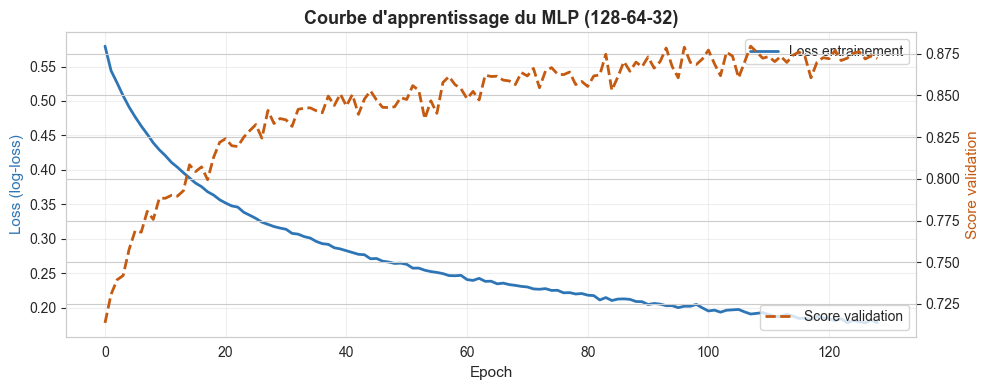

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(mlp_custom.loss_curve_, color='#2E75B6', linewidth=2, label='Loss entrainement')
if hasattr(mlp_custom, 'validation_scores_') and mlp_custom.validation_scores_:
    ax2 = ax.twinx()
    ax2.plot(mlp_custom.validation_scores_, color='#C55A11', linewidth=2,
             linestyle='--', label='Score validation')
    ax2.set_ylabel('Score validation', color='#C55A11')
    ax2.legend(loc='lower right')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log-loss)', color='#2E75B6')
ax.set_title("Courbe d'apprentissage du MLP (128-64-32)", fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## Interpretation Courbe d'apprentissage du MLP (128-64-32)

Ce graphique montre un **problème de surapprentissage (overfitting)** :

- La **loss d'entraînement** (bleu) descend régulièrement et continuellement jusqu'à ~0.19 — le modèle apprend bien les données d'entraînement.
- Le **score de validation** (orange pointillé) plafonne très tôt (~epoch 15-20) autour de 0.85-0.87, puis oscille sans s'améliorer.
- Ce décrochage entre les deux courbes indique que le MLP **mémorise les données d'entraînement** sans généraliser, ce qui explique ses mauvaises performances en AUC sur le graphique 6.


## 8. Visualisations et Comparaison Globale

In [27]:
summary = pd.DataFrame({
    name: {
        'CV AUC':   round(v['cv_auc'], 4),
        'Test AUC': round(v['test_auc'], 4),
        'Accuracy': round(v['test_acc'], 4),
        'F1-Score': round(v['test_f1'], 4),
    }
    for name, v in results.items()
}).T.sort_values('Test AUC', ascending=False)

print("=" * 65)
print("        COMPARAISON DES MODELES — RESULTATS SUR TEST SET")
print("=" * 65)
print(summary.to_string())
print("=" * 65)
print(f"Meilleur modele (AUC) : {summary['Test AUC'].idxmax()}")
print(f"   AUC-ROC  = {summary['Test AUC'].max():.4f}")
print(f"   F1-Score = {summary.loc[summary['Test AUC'].idxmax(), 'F1-Score']:.4f}")
summary

        COMPARAISON DES MODELES — RESULTATS SUR TEST SET
                        CV AUC  Test AUC  Accuracy  F1-Score
Gradient Boosting       0.7901    0.7983    0.8932    0.2897
Random Forest           0.7832    0.7932    0.8940    0.3174
Voting Ensemble         0.7808    0.7931    0.8958    0.3695
AdaBoost                0.7736    0.7824    0.8920    0.2638
Decision Tree           0.7460    0.7589    0.8090    0.4063
MLP (64-32)             0.8849    0.7367    0.7775    0.3685
Logistic Regression     0.7320    0.7332    0.6404    0.3165
KNN (k=11)              0.9172    0.7255    0.7170    0.3358
Naive Bayes             0.7124    0.7120    0.5482    0.2901
MLP (128-64-32)         0.9311    0.6838    0.7924    0.3081
MLP Custom (128-64-32)  0.0000    0.6838    0.7924    0.3081
Meilleur modele (AUC) : Gradient Boosting
   AUC-ROC  = 0.7983
   F1-Score = 0.2897


,CV AUC,Test AUC,Accuracy,F1-Score
Gradient Boosting,0.7901,0.7983,0.8932,0.2897
Random Forest,0.7832,0.7932,0.8940,0.3174
Voting Ensemble,0.7808,0.7931,0.8958,0.3695
AdaBoost,0.7736,0.7824,0.8920,0.2638
Decision Tree,0.7460,0.7589,0.8090,0.4063
MLP (64-32),0.8849,0.7367,0.7775,0.3685
Logistic Regression,0.7320,0.7332,0.6404,0.3165
KNN (k=11),0.9172,0.7255,0.7170,0.3358
Naive Bayes,0.7124,0.7120,0.5482,0.2901
MLP (128-64-32),0.9311,0.6838,0.7924,0.3081


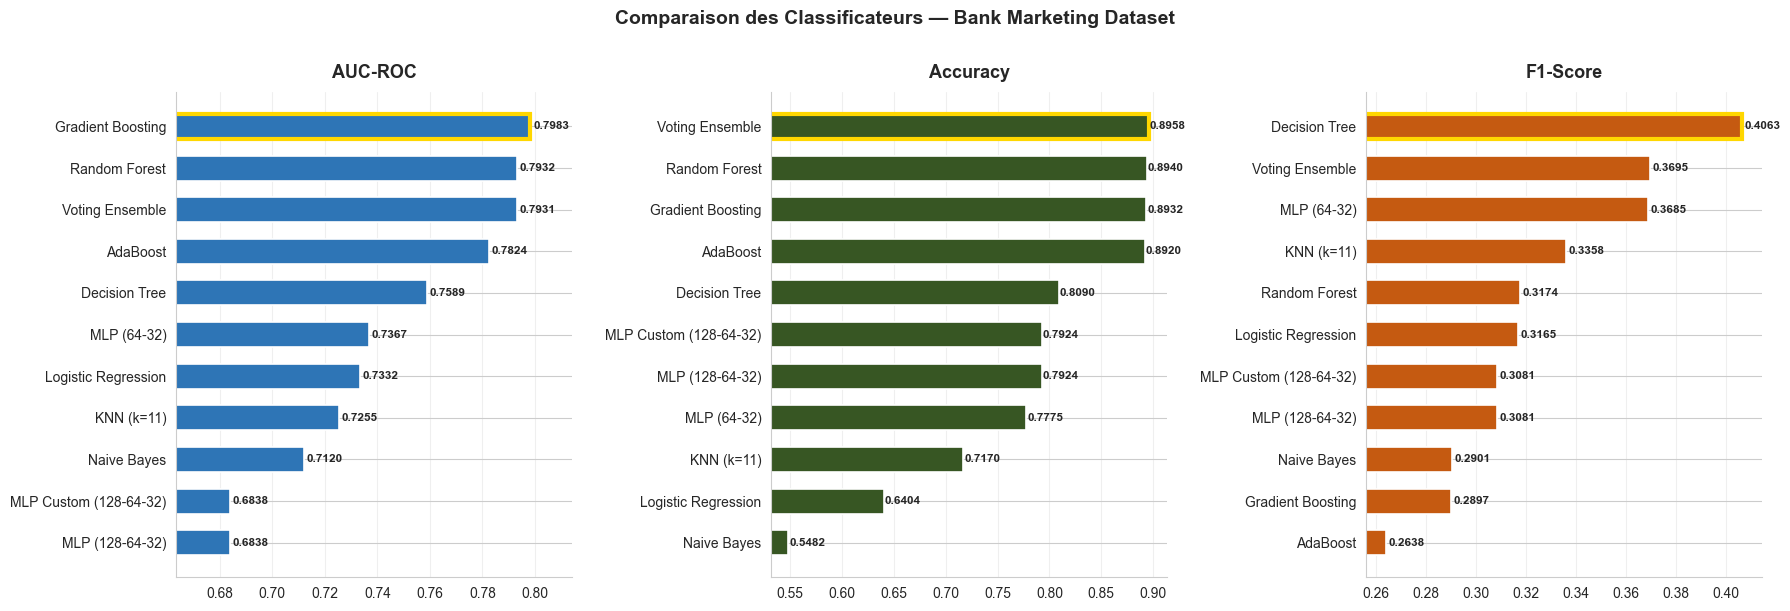

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['Test AUC', 'Accuracy', 'F1-Score']
titles  = ['AUC-ROC', 'Accuracy', 'F1-Score']
colors  = ['#2E75B6', '#375623', '#C55A11']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    data = summary[metric].sort_values(ascending=True)
    bars = ax.barh(data.index, data.values, color=color,
                   edgecolor='white', linewidth=1.2, height=0.6)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlim(data.min() * 0.97, data.max() * 1.02)
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8.5, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    best_idx = list(data.index).index(data.idxmax())
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.suptitle('Comparaison des Classificateurs — Bank Marketing Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretation de la comparaison des classifeur              

Trois métriques sont comparées sur tous les modèles testés :

- **AUC-ROC** (capacité discriminante) : **Gradient Boosting** est le meilleur (0.7983), suivi de Random Forest (0.7932) et Voting Ensemble (0.7931). Les MLP profonds (128-64-32) sont les moins performants (0.68).
- **Accuracy** : le **Voting Ensemble** arrive en tête (0.8958), mais cette métrique est moins fiable sur des classes déséquilibrées.
- **F1-Score** : le **Decision Tree** est paradoxalement le meilleur (0.4063), suggérant qu'il capture mieux la classe minoritaire (Yes), au prix d'un AUC plus faible. Les boosting (AdaBoost, Gradient Boosting) ont des F1 faibles malgré un bon AUC — ils minimisent les faux positifs mais ratent beaucoup de vrais "Yes".

>  **Tension importante** : Gradient Boosting est le meilleur en AUC mais très faible en F1 (0.29). Dans un contexte bancaire, détecter les souscripteurs potentiels (rappel) est souvent plus important que la précision pure.



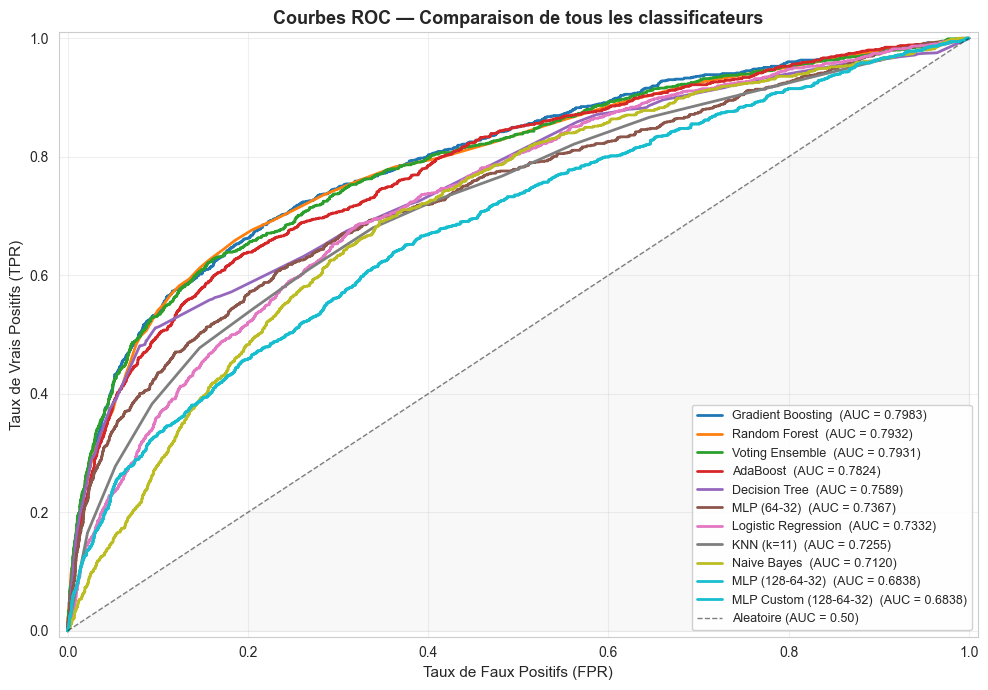

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.get_cmap('tab10')

for i, (name, v) in enumerate(sorted(results.items(),
                                      key=lambda x: x[1]['test_auc'], reverse=True)):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    ax.plot(fpr, tpr, linewidth=2, color=cmap(i),
            label=f"{name}  (AUC = {v['test_auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatoire (AUC = 0.50)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.set_title('Courbes ROC — Comparaison de tous les classificateurs',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()




## Interpretation Courbes ROC de tous les classificateurs

Ce graphique synthétise visuellement la **capacité discriminante** de chaque modèle :

- Les courbes les plus hautes (coin supérieur gauche) sont les meilleures. **Gradient Boosting**, **Random Forest** et **Voting Ensemble** dominent nettement.
- La diagonale pointillée grise représente un **classifieur aléatoire (AUC=0.50)** — référence de base à battre.
- Les MLP (128-64-32) en bleu clair et cyan sont proches de la diagonale, confirmant leur sous-performance.
- La séparation entre les courbes est surtout visible pour des **FPR faibles (0 à 0.3)**, zone la plus critique pour cibler efficacement les clients sans trop de faux positifs.






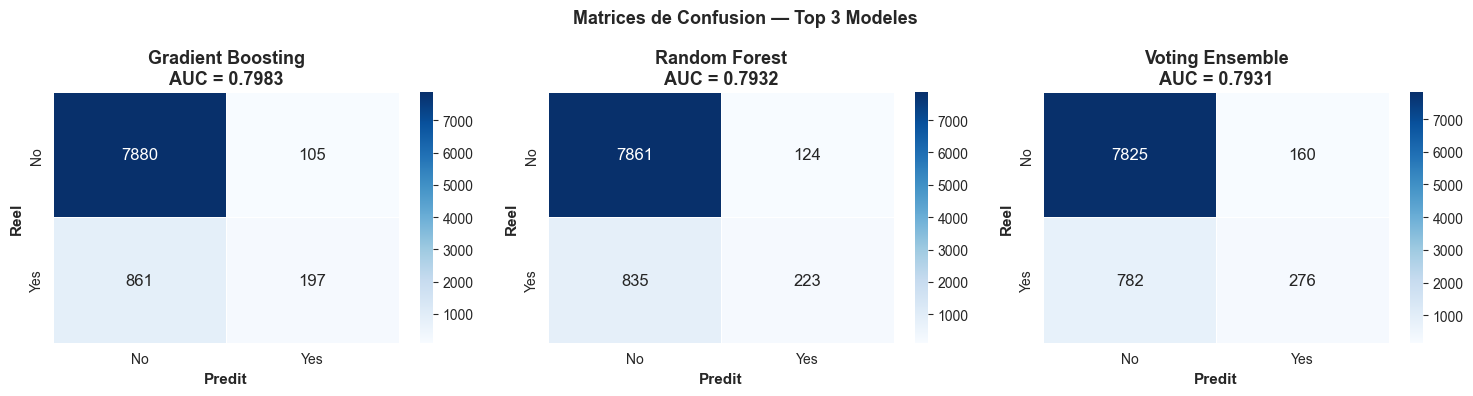

In [30]:
top3 = summary['Test AUC'].head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                linewidths=0.5, annot_kws={'size': 12})
    ax.set_xlabel('Predit', fontweight='bold')
    ax.set_ylabel('Reel', fontweight='bold')
    ax.set_title(f'{name}\nAUC = {results[name]["test_auc"]:.4f}', fontweight='bold')

plt.suptitle('Matrices de Confusion — Top 3 Modeles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Optimisation des Hyperparametres — GridSearchCV

Le **GridSearchCV** explore toutes les combinaisons de parametres possibles
et selectionne celle qui maximise le score AUC-ROC en validation croisee.

In [31]:
print("GridSearchCV en cours (environ 1-2 min)...")

param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight':      ['balanced']
}

gs = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = 'roc_auc',
    n_jobs     = 1,
    verbose    = 1
)

gs.fit(X_train, y_train)

best_rf   = gs.best_estimator_
y_pred_gs = best_rf.predict(X_test)
y_prob_gs = best_rf.predict_proba(X_test)[:, 1]

print(f"GridSearchCV termine !")
print(f"   Meilleurs parametres : {gs.best_params_}")
print(f"   Meilleur CV AUC      : {gs.best_score_:.4f}")
print(f"{'='*50}")
print(f"   AUC-ROC  sur test : {roc_auc_score(y_test, y_prob_gs):.4f}")
print(f"   Accuracy sur test : {accuracy_score(y_test, y_pred_gs):.4f}")
print(f"   F1-Score sur test : {f1_score(y_test, y_pred_gs):.4f}")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_gs,
      target_names=['Non Souscrit (0)', 'Souscrit (1)']))

# CORRECTION : ajout du RF optimise dans results pour comparaison complete
results['RF Optimise (GridSearch)'] = {
    'clf': best_rf, 'use_sc': False,
    'cv_auc': gs.best_score_, 'cv_std': 0,
    'test_acc': accuracy_score(y_test, y_pred_gs),
    'test_auc': roc_auc_score(y_test, y_prob_gs),
    'test_f1':  f1_score(y_test, y_pred_gs),
    'y_prob': y_prob_gs, 'y_pred': y_pred_gs,
}

print(f"RF Optimise ajoute au tableau comparatif.")

GridSearchCV en cours (environ 1-2 min)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV termine !
   Meilleurs parametres : {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
   Meilleur CV AUC      : 0.7945
   AUC-ROC  sur test : 0.8022
   Accuracy sur test : 0.8460
   F1-Score sur test : 0.4721
                  precision    recall  f1-score   support

Non Souscrit (0)       0.94      0.88      0.91      7985
    Souscrit (1)       0.39      0.59      0.47      1058

        accuracy                           0.85      9043
       macro avg       0.67      0.73      0.69      9043
    weighted avg       0.88      0.85      0.86      9043

RF Optimise ajoute au tableau comparatif.


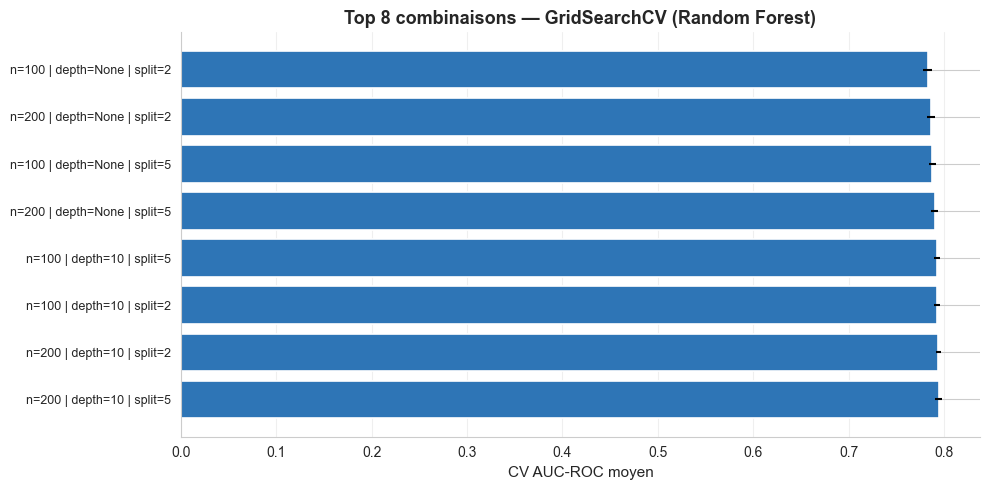

In [32]:
results_gs = pd.DataFrame(gs.cv_results_)
top_results = results_gs.sort_values('mean_test_score', ascending=False).head(8)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top_results)), top_results['mean_test_score'],
        xerr=top_results['std_test_score'],
        color='#2E75B6', edgecolor='white', linewidth=1.2)
labels = [
    f"n={r['param_n_estimators']} | depth={r['param_max_depth']} | split={r['param_min_samples_split']}"
    for _, r in top_results.iterrows()
]
ax.set_yticks(range(len(top_results)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('CV AUC-ROC moyen')
ax.set_title('Top 8 combinaisons — GridSearchCV (Random Forest)', fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('gridsearch_results.png', dpi=120, bbox_inches='tight')
plt.show()

## Interpretation GridSearchCV sur Random Forest

Ce graphique compare les **8 meilleures combinaisons d'hyperparamètres** testées sur Random Forest :

- Toutes les combinaisons convergent vers un **AUC-ROC moyen de ~0.79**, avec des écarts minimes.
- Les configurations avec **depth=10** et **n=200 arbres** semblent légèrement supérieures (barres les plus longues, en bas).
- La faible variance entre les combinaisons indique que le Random Forest est **robuste aux hyperparamètres** dans cette plage — pas de gain majeur attendu par tuning supplémentaire.
- Les barres d'erreur (intervalles de confiance) sont très faibles, confirmant la **stabilité des résultats en cross-validation**.


## 10. Importance des Variables (Feature Importance)

Calculee via le **Random Forest optimise** (GridSearchCV).
Note : `duree` a ete supprimee — les resultats refletent les vraies variables
utilisables en production.

In [33]:
# Mise a jour du tableau comparatif complet (inclut RF optimise et MLP custom)
summary = pd.DataFrame({
    name: {
        'CV AUC':   round(v['cv_auc'], 4),
        'Test AUC': round(v['test_auc'], 4),
        'Accuracy': round(v['test_acc'], 4),
        'F1-Score': round(v['test_f1'], 4),
    }
    for name, v in results.items()
}).T.sort_values('Test AUC', ascending=False)

print("=" * 65)
print("   TABLEAU FINAL — TOUS LES MODELES")
print("=" * 65)
print(summary.to_string())
print("=" * 65)

best_name = summary['Test AUC'].idxmax()
print(f"\nMeilleur modele : {best_name}")
print(f"   AUC-ROC  = {summary['Test AUC'].max():.4f}")
print(f"   F1-Score = {summary.loc[best_name, 'F1-Score']:.4f}")
summary

   TABLEAU FINAL — TOUS LES MODELES
                          CV AUC  Test AUC  Accuracy  F1-Score
RF Optimise (GridSearch)  0.7945    0.8022    0.8460    0.4721
Gradient Boosting         0.7901    0.7983    0.8932    0.2897
Random Forest             0.7832    0.7932    0.8940    0.3174
Voting Ensemble           0.7808    0.7931    0.8958    0.3695
AdaBoost                  0.7736    0.7824    0.8920    0.2638
Decision Tree             0.7460    0.7589    0.8090    0.4063
MLP (64-32)               0.8849    0.7367    0.7775    0.3685
Logistic Regression       0.7320    0.7332    0.6404    0.3165
KNN (k=11)                0.9172    0.7255    0.7170    0.3358
Naive Bayes               0.7124    0.7120    0.5482    0.2901
MLP (128-64-32)           0.9311    0.6838    0.7924    0.3081
MLP Custom (128-64-32)    0.0000    0.6838    0.7924    0.3081

Meilleur modele : RF Optimise (GridSearch)
   AUC-ROC  = 0.8022
   F1-Score = 0.4721


,CV AUC,Test AUC,Accuracy,F1-Score
RF Optimise (GridSearch),0.7945,0.8022,0.8460,0.4721
Gradient Boosting,0.7901,0.7983,0.8932,0.2897
Random Forest,0.7832,0.7932,0.8940,0.3174
Voting Ensemble,0.7808,0.7931,0.8958,0.3695
AdaBoost,0.7736,0.7824,0.8920,0.2638
Decision Tree,0.7460,0.7589,0.8090,0.4063
MLP (64-32),0.8849,0.7367,0.7775,0.3685
Logistic Regression,0.7320,0.7332,0.6404,0.3165
KNN (k=11),0.9172,0.7255,0.7170,0.3358
Naive Bayes,0.7124,0.7120,0.5482,0.2901


In [34]:
feat_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top variables les plus importantes :")
print("-" * 40)
for feat, imp in feat_importance.head(10).items():
    bar = "#" * int(imp * 100)
    print(f"  {feat:<25} {imp:.4f}  {bar}")

Top variables les plus importantes :
----------------------------------------
  type_contact              0.1216  ############
  mois_sin                  0.1082  ##########
  resultat_precedent        0.0983  #########
  jours_depuis_contact      0.0886  ########
  age                       0.0872  ########
  jour                      0.0850  ########
  solde                     0.0823  ########
  mois_cos                  0.0823  ########
  pret_immobilier           0.0776  #######
  contacts_precedents       0.0449  ####


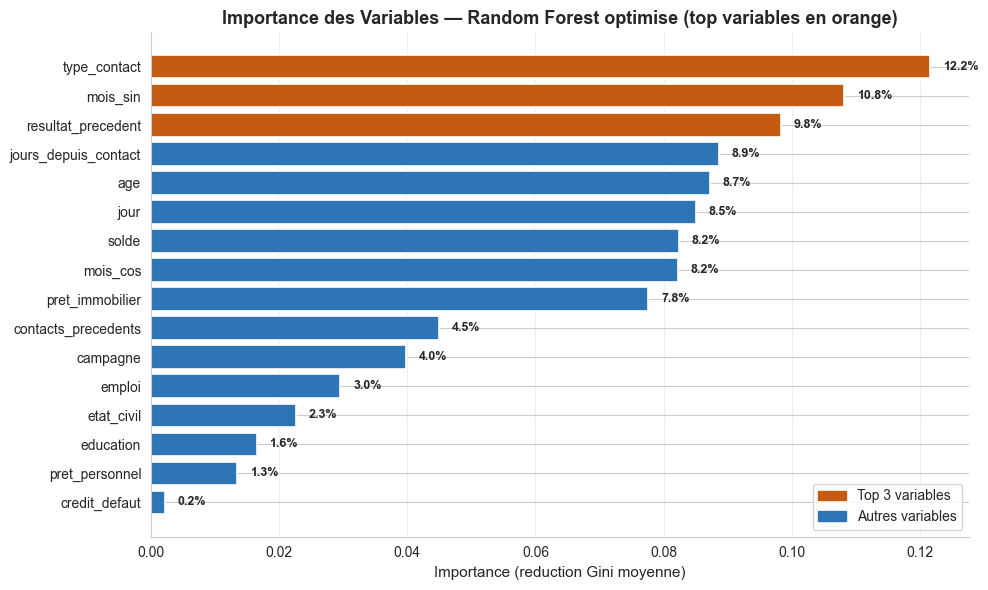

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_fi = ['#C55A11' if i < 3 else '#2E75B6' for i in range(len(feat_importance))]
bars = ax.barh(feat_importance.index[::-1], feat_importance.values[::-1],
               color=colors_fi[::-1], edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, feat_importance.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Importance (reduction Gini moyenne)', fontsize=11)
ax.set_title("Importance des Variables — Random Forest optimise (top variables en orange)",
             fontweight='bold', fontsize=13)
top_patch   = mpatches.Patch(color='#C55A11', label='Top 3 variables')
other_patch = mpatches.Patch(color='#2E75B6', label='Autres variables')
ax.legend(handles=[top_patch, other_patch], loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# MDI — Mean Decrease in Impurity (Random Forest)

## 1. L'indice de Gini — mesure du désordre

L'indice de Gini mesure l'**impureté d'un nœud**, c'est-à-dire à quel point
les classes (Yes/No) sont mélangées dans ce nœud.

$$\text{Gini}(n) = 1 - \sum_{k=1}^{K} p_k^2$$

où $p_k$ est la proportion de la classe $k$ dans le nœud $n$.

| Situation | Calcul | Gini | Interprétation |
|---|---|---|---|
| 100% No, 0% Yes | 1 − (1² + 0²) | **0.00** | Nœud parfaitement pur |
| 80% No, 20% Yes | 1 − (0.8² + 0.2²) | **0.32** | Nœud assez pur |
| 50% No, 50% Yes | 1 − (0.5² + 0.5²) | **0.50** | Nœud maximalement impur |

> Plus Gini est proche de 0, plus le nœud est **pur** (une seule classe domine).
> Plus Gini est proche de 0.5, plus le nœud est **impur** (classes mélangées).

---

## 2. Le ΔGini — gain d'un split

Quand un nœud parent est divisé en deux nœuds enfants par une variable $f$,
on mesure la **réduction d'impureté** apportée par ce split :

$$\Delta\text{Gini}(f) = \text{Gini}(\text{parent}) - \left( \frac{N_g}{N} \cdot \text{Gini}(\text{gauche}) + \frac{N_d}{N} \cdot \text{Gini}(\text{droite}) \right)$$

où $N_g$, $N_d$, $N$ sont les effectifs des nœuds gauche, droit et parent.

### Exemple concret (jours\_depuis\_contact < 60)

```
Nœud parent    : 800 No + 200 Yes  →  Gini = 0.32   (N = 1000)
Nœud gauche    : 680 No +  70 Yes  →  Gini = 0.17   (N = 750)
Nœud droit     : 120 No + 130 Yes  →  Gini = 0.50   (N = 250)

Gini pondéré = (750/1000) × 0.17 + (250/1000) × 0.50
             = 0.1275 + 0.125 = 0.2525

ΔGini = 0.32 − 0.2525 = 0.0675
```

> Ce split a réduit l'impureté de **0.0675**.
> Plus ΔGini est grand, plus la variable est utile à ce nœud.



## 3. La formule MDI complète

$$\text{Importance}(f) = \frac{1}{N_{\text{arbres}}} \sum_{\text{arbres}} \sum_{\substack{\text{nœuds} \\ \text{utilisant } f}} \frac{N_{\text{nœud}}}{N_{\text{total}}} \cdot \Delta\text{Gini}(f)$$

**Décomposition terme par terme :**

| Terme | Signification |
|---|---|
| $\frac{1}{N_{\text{arbres}}}$ | Moyenne sur les 100 arbres de la forêt |
| $\sum_{\text{arbres}}$ | Somme sur chaque arbre |
| $\sum_{\text{nœuds utilisant } f}$ | Somme sur chaque nœud où $f$ est utilisée comme variable de split |
| $\frac{N_{\text{nœud}}}{N_{\text{total}}}$ | Pondération par la taille du nœud |
| $\Delta\text{Gini}(f)$ | Gain de pureté apporté par $f$ à ce nœud |

### Normalisation finale

$$\text{Importance\_normalisée}(f) = \frac{\text{Importance}(f)}{\sum_{j} \text{Importance}(j)}$$

Ce qui garantit que la somme de toutes les importances vaut **1.0**.



## 4. Processus complet étape par étape

```
Pour chaque arbre (1 à 100) :
  └── Pour chaque nœud de l'arbre :
        └── Pour chaque variable candidate f :
              1. Calculer Gini(parent)
              2. Tester tous les seuils possibles de f
              3. Calculer Gini pondéré des enfants
              4. ΔGini(f) = Gini(parent) − Gini pondéré
        └── Choisir la variable f* avec le ΔGini le plus grand
        └── Accumuler ΔGini(f*) dans l'importance de f*

Importance finale(f) = moyenne des ΔGini accumulés / somme totale
```


## 5. Résultat typique — dataset bancaire

| Variable | Importance | Interprétation |
|---|---|---|
| jours\_depuis\_contact | 0.182 | Délai depuis dernier contact — très discriminant |
| resultat\_precedent | 0.154 | Succès campagne précédente — signal fort |
| solde | 0.121 | Capacité financière du client |
| age | 0.099 | Profil démographique |
| campagne | 0.088 | Nombre de contacts — trop = négatif |
| contacts\_precedents | 0.075 | Historique de la relation |



## 6. Limites du MDI

| Limite | Explication | Solution |
|---|---|---|
| Biais vers les variables continues | Plus de seuils possibles → plus de chances de gagner | Permutation Importance |
| Calculé sur les données d'entraînement | Peut surestimer les variables qui fittent le bruit | Permutation sur le test set |
| Corrélation entre variables | L'importance est partagée entre variables corrélées | SHAP values |





> **En résumé :** le MDI répond à la question
> *"En moyenne, de combien cette variable réduit-elle le désordre dans les nœuds
> de tous les arbres de la forêt ?"*
> Une importance élevée signifie que la variable crée des splits nets et utiles,
> séparant efficacement les souscripteurs des non-souscripteurs.


## 11. Prediction sur un Nouveau Client

Demonstration de l'utilisation du meilleur modele pour scorer un nouveau client.
Le client fictif n'inclut pas `duree` puisque cette variable n'est pas disponible avant l'appel.

In [36]:
nouveau_client_brut = pd.DataFrame([{
    'age':                  42,
    'emploi':               'management',
    'etat_civil':           'married',
    'education':            'tertiary',
    'credit_defaut':        'no',
    'solde':                2500,
    'pret_immobilier':      'no',
    'pret_personnel':       'no',
    'type_contact':         'cellular',
    'jour':                 15,
    'mois':                 'jun',
    'campagne':             1,
    'jours_depuis_contact': -1,
    'contacts_precedents':  0,
    'resultat_precedent':   'unknown',
}])

nouveau_client = nouveau_client_brut.copy()

for col in ['emploi', 'education', 'etat_civil', 'resultat_precedent',
            'pret_immobilier', 'pret_personnel', 'credit_defaut']:
    nouveau_client[col] = encoders[col].transform(nouveau_client[col])

nouveau_client['type_contact'] = nouveau_client['type_contact'].map(mapping_contact)
nouveau_client['mois']         = nouveau_client['mois'].map(mapping_mois)
nouveau_client['mois_sin']     = np.sin(2 * np.pi * nouveau_client['mois'] / 12)
nouveau_client['mois_cos']     = np.cos(2 * np.pi * nouveau_client['mois'] / 12)
nouveau_client = nouveau_client.drop(columns=['mois'])
nouveau_client = nouveau_client[X.columns]

print("=" * 55)
print("   SCORING DU NOUVEAU CLIENT")
print("=" * 55)
print(f"  Age      : 42 ans")
print(f"  Emploi   : Management")
print(f"  Solde    : 2500 euros")
print(f"  Campagne : 1er contact")
print(f"  Mois     : Juin")
print("=" * 55)

best_model_name = summary['Test AUC'].idxmax()
best_clf_pred   = results[best_model_name]['clf']
use_sc_pred     = results[best_model_name]['use_sc']

X_new = scaler.transform(nouveau_client) if use_sc_pred else nouveau_client
proba = best_clf_pred.predict_proba(X_new)[0, 1]
pred  = best_clf_pred.predict(X_new)[0]

print(f"\nMeilleur modele : {best_model_name}")
print(f"Probabilite de souscription : {proba*100:.1f}%")
print(f"Decision : {'SOUSCRIPTION PROBABLE (yes)' if pred == 1 else 'NON SOUSCRIPTION (no)'}")

print("\nScores de tous les modeles :")
print("-" * 45)
for name, v in sorted(results.items(), key=lambda x: x[1]['test_auc'], reverse=True):
    clf_i = v['clf']
    X_i   = scaler.transform(nouveau_client) if v['use_sc'] else nouveau_client
    p     = clf_i.predict_proba(X_i)[0, 1]
    bar   = "#" * int(p * 25)
    print(f"  {name:<28} {p*100:5.1f}%  {bar}")

   SCORING DU NOUVEAU CLIENT
  Age      : 42 ans
  Emploi   : Management
  Solde    : 2500 euros
  Campagne : 1er contact
  Mois     : Juin

Meilleur modele : RF Optimise (GridSearch)
Probabilite de souscription : 75.3%
Decision : SOUSCRIPTION PROBABLE (yes)

Scores de tous les modeles :
---------------------------------------------
  RF Optimise (GridSearch)      75.3%  ##################
  Gradient Boosting             35.2%  ########
  Random Forest                 59.0%  ##############
  Voting Ensemble               51.7%  ############
  AdaBoost                      49.8%  ############
  Decision Tree                 83.9%  ####################
  MLP (64-32)                   84.2%  #####################
  Logistic Regression           70.0%  #################
  KNN (k=11)                   100.0%  #########################
  Naive Bayes                   78.9%  ###################
  MLP (128-64-32)               87.7%  #####################
  MLP Custom (128-64-32)        87.7% 

### Rapport de classification du meilleur modele

In [37]:
best_name = summary['Test AUC'].idxmax()

print("=" * 60)
print(f"   RAPPORT DE CLASSIFICATION — {best_name}")
print("=" * 60)
print(classification_report(
    y_test,
    results[best_name]['y_pred'],
    target_names=['Non Souscrit (0)', 'Souscrit (1)']
))

print("Metriques d'evaluation :")
print(f"   AUC-ROC  : {results[best_name]['test_auc']:.4f}")
print(f"   Accuracy : {results[best_name]['test_acc']:.4f}")
print(f"   F1-Score : {results[best_name]['test_f1']:.4f}")
print()
print("Rappel sur les metriques :")
print("  AUC-ROC  : capacite de discrimination (1.0 = parfait, 0.5 = aleatoire)")
print("  Accuracy : proportion de predictions correctes")
print("  F1-Score : equilibre precision/rappel (important pour classes desequilibrees)")
print("  Precision: vrais positifs parmi les positifs predits")
print("  Rappel   : vrais positifs detectes parmi tous les positifs reels")

   RAPPORT DE CLASSIFICATION — RF Optimise (GridSearch)
                  precision    recall  f1-score   support

Non Souscrit (0)       0.94      0.88      0.91      7985
    Souscrit (1)       0.39      0.59      0.47      1058

        accuracy                           0.85      9043
       macro avg       0.67      0.73      0.69      9043
    weighted avg       0.88      0.85      0.86      9043

Metriques d'evaluation :
   AUC-ROC  : 0.8022
   Accuracy : 0.8460
   F1-Score : 0.4721

Rappel sur les metriques :
  AUC-ROC  : capacite de discrimination (1.0 = parfait, 0.5 = aleatoire)
  Accuracy : proportion de predictions correctes
  F1-Score : equilibre precision/rappel (important pour classes desequilibrees)
  Precision: vrais positifs parmi les positifs predits
  Rappel   : vrais positifs detectes parmi tous les positifs reels



## 12. Conclusion


### Reponses aux questions du projet

1. **Quels classifieurs sont utiles en banque ?**
   - Regression Logistique : interpretabilite reglementaire, coefficients lisibles
   - Random Forest / Gradient Boosting : haute performance sur donnees tabulaires
   - MLP : capture des relations non-lineaires complexes entre les variables

2. **Comment creer un ensemble de modeles ?**
   - `VotingClassifier(voting='soft')` combinant RF + GB + AdaBoost + LR
   - Le vote soft moyenne les probabilites, plus robuste que le vote majoritaire

3. **Comment creer un classificateur base sur un reseau de neurones ?**
   - `MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', alpha=0.001)`
   - Avec early stopping et learning rate adaptatif pour eviter le surapprentissage

4. **Comment estimer la precision d'un modele ?**
   - Validation croisee `StratifiedKFold(n_splits=5)` preservant les proportions de classes
   - Metriques : AUC-ROC (discriminante), F1-Score (equilibre precision/rappel)
   - `classification_report()` : precision, rappel et F1 par classe
   - Matrice de confusion : analyse detaillee des erreurs de prediction

